<a href="https://colab.research.google.com/github/shahriariit/ML_Airlines_Services/blob/main/dataset_1_topic_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q bertopic
!pip install -q sentence-transformers
!pip install -q umap-learn hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 13.5 MB/s eta 0:00:00


In [3]:
!pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.7 MB/s eta 0:00:00


In [4]:
import re
import os
import shap
import pandas as pd
from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from umap import UMAP
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sentence_transformers import SentenceTransformer
import plotly.graph_objects as go
import numpy as np

sns.set(style="whitegrid")

In [5]:
url = "https://raw.githubusercontent.com/shahriariit/opendataset/master/Bangladesh-airline-dataset.csv"

df = pd.read_csv(url)
df = df.dropna(subset=["review"]).reset_index(drop=True)

print(df.head())
print(df["target"].value_counts())

                                              review    target  \
0  Worst experience at Dhaka airport. Delayed fli...  Negative   
1  Good value for money. Somethimes you might con...  Positive   
2  Very good airlines ever i see. Good service fo...  Positive   
3  I naver used Biman Bangladesh and it was first...  Positive   
4  I have travelled from London to Dhaka direct f...  Negative   

                                          title                    airline  
0                       Worse Flying experience  Biman_Bangladesh_Airlines  
1  Good value for price and food was excellent.  Biman_Bangladesh_Airlines  
2                                     excellent  Biman_Bangladesh_Airlines  
3                    Fantastic food and service  Biman_Bangladesh_Airlines  
4    Rude flight supervisor at the airport desk  Biman_Bangladesh_Airlines  
target
Negative    349
Positive    349
Mixed       349
Name: count, dtype: int64


In [6]:
texts = df["review"].astype(str).tolist()

In [7]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

cluster_model = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5
)

topic_model = BERTopic(
    embedding_model="all-MiniLM-L6-v2",
    umap_model=umap_model,
    hdbscan_model=cluster_model,   # KMeans used here
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

In [8]:
topics, probs = topic_model.fit_transform(texts)

2026-05-10 19:00:42,868 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/33 [00:00<?, ?it/s]

2026-05-10 19:01:21,333 - BERTopic - Embedding - Completed ✓
2026-05-10 19:01:21,336 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-10 19:01:29,450 - BERTopic - Dimensionality - Completed ✓
2026-05-10 19:01:29,452 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-10 19:01:29,548 - BERTopic - Cluster - Completed ✓
2026-05-10 19:01:29,551 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-10 19:01:29,675 - BERTopic - Representation - Completed ✓


In [13]:
topic_info = topic_model.get_topic_info()
print(topic_info)

topic_info.to_csv("topic_info.csv", index=False)

   Topic  Count                              Name  \
0      0    369        0_flight_good_service_time   
1      1    214        1_flight_good_time_service   
2      2    178       2_flight_biman_time_airport   
3      3    163  3_bangladesh_biman_good_airlines   
4      4    123         4_biman_food_flight_class   

                                      Representation  \
0  [flight, good, service, time, food, airline, c...   
1  [flight, good, time, service, food, airlines, ...   
2  [flight, biman, time, airport, hours, plane, p...   
3  [bangladesh, biman, good, airlines, flight, se...   
4  [biman, food, flight, class, service, business...   

                                 Representative_Docs  
0  [The staffs are friendly and the flight servic...  
1  [Traveled twice in 2 months. Went to Chittagon...  
2  [Recently, London -Dhaka-Sylhet. When we arriv...  
3  [Biman Bangladesh is one of oldest airlines in...  
4  [Biman is a simple airline with an acceptable ...  


In [14]:
topic_model.set_topic_labels({
    0: "General Positive Experience",
    1: "Operational & Airport Issues",
    2: "In-flight Comfort & Service",
    3: "Class-based Experience",
    4: "Flight Delays"
})

In [15]:
top_n = 300
n_words = 10
topics_to_show = topic_model.get_topics()
topic_ids = [t for t in topics_to_show.keys() if t != -1][:top_n]

# Layout settings
cols = 3
rows = -(-len(topic_ids) // cols)

fig = make_subplots(
    rows=rows,
    cols=cols,
    subplot_titles=[f"Topic {t}" for t in topic_ids]  # ← change this line
)

for i, topic_id in enumerate(topic_ids):
    row = i // cols + 1
    col = i % cols + 1

    words_scores = topic_model.get_topic(topic_id)[:n_words]
    words  = [w for w, _ in words_scores][::-1]
    scores = [s for _, s in words_scores][::-1]

    fig.add_trace(
        go.Bar(
            x=scores,
            y=words,
            orientation="h",
            showlegend=False
        ),
        row=row,
        col=col
    )

fig.update_layout(
    height=400 * rows,
    width=1100,
    #title_text="Topic Word Distributions",
    template="plotly_white"
)

fig.write_html("topic_distribution.html")
fig.show()

In [16]:
df["Target_Label"] = df["target"]

df_analysis = df.copy()
df_analysis["topic"] = topics

In [17]:
def radar_plot(topic_id):

    subset = df_analysis[df_analysis["topic"] == topic_id]
    dist = subset["Target_Label"].value_counts(normalize=True)

    labels = ["Positive", "Negative", "Mixed"]
    values = [dist.get(l, 0) for l in labels]

    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    values += values[:1]
    angles += angles[:1]

    fig, ax = plt.subplots(subplot_kw=dict(polar=True))
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    plt.show()

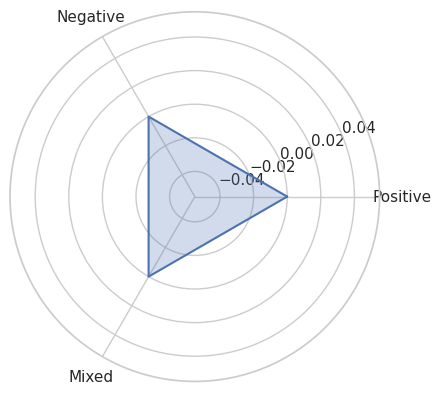

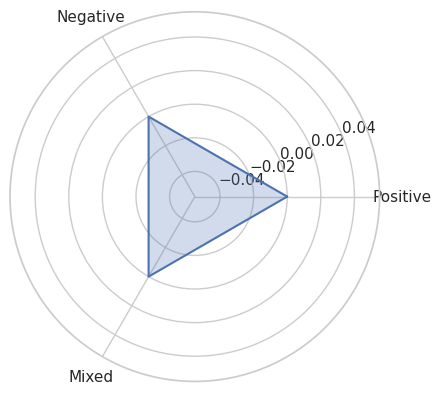

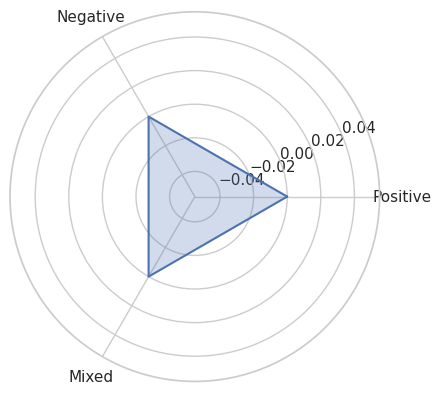

In [ ]:
radar_plot(0)
radar_plot(4)
radar_plot(3)

In [18]:
source = df_analysis["topic"]
target = df_analysis["Target_Label"]

labels = list(set(source)) + list(set(target))

mapping = {v:i for i,v in enumerate(labels)}

src = [mapping[s] for s in source]
tgt = [mapping[t] for t in target]

fig = go.Figure(go.Sankey(
    node=dict(label=labels),
    link=dict(source=src, target=tgt, value=[1]*len(src))
))

fig.show()

In [19]:

source = df_analysis["topic"]
target = df_analysis["Target_Label"]

labels = list(set(source)) + list(set(target))

mapping = {v:i for i,v in enumerate(labels)}

src = [mapping[s] for s in source]
tgt = [mapping[t] for t in target]

fig = go.Figure(go.Sankey(
    node=dict(label=labels),
    link=dict(source=src, target=tgt, value=[1]*len(src))
))

fig.show()

In [20]:
fig = topic_model.visualize_topics()
fig.update_layout(title="")
fig.write_html("topic_map.html")
fig.show()

In [21]:
fig = topic_model.visualize_documents(texts)
fig.update_layout(title="")
fig.write_html("document_clusters.html")
fig.show()

In [23]:
df["Target_Label"] = df["target"]

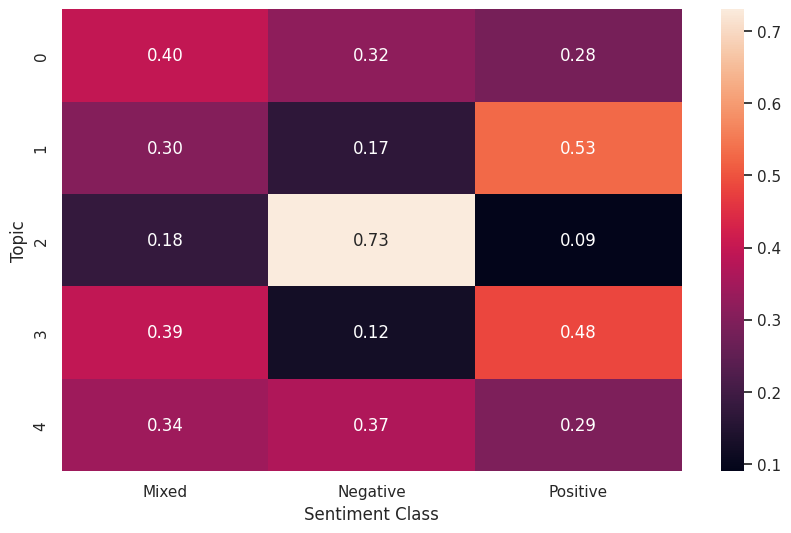

In [24]:
df_analysis = df.copy()
df_analysis["topic"] = topics

pivot = pd.crosstab(
    df_analysis["topic"],
    df_analysis["Target_Label"],
    normalize='index'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".2f")

#plt.title("Topic-wise Distribution of Customer Sentiment")
plt.xlabel("Sentiment Class")
plt.ylabel("Topic")

plt.savefig("topic_vs_target.png", dpi=300, bbox_inches='tight')
plt.show()

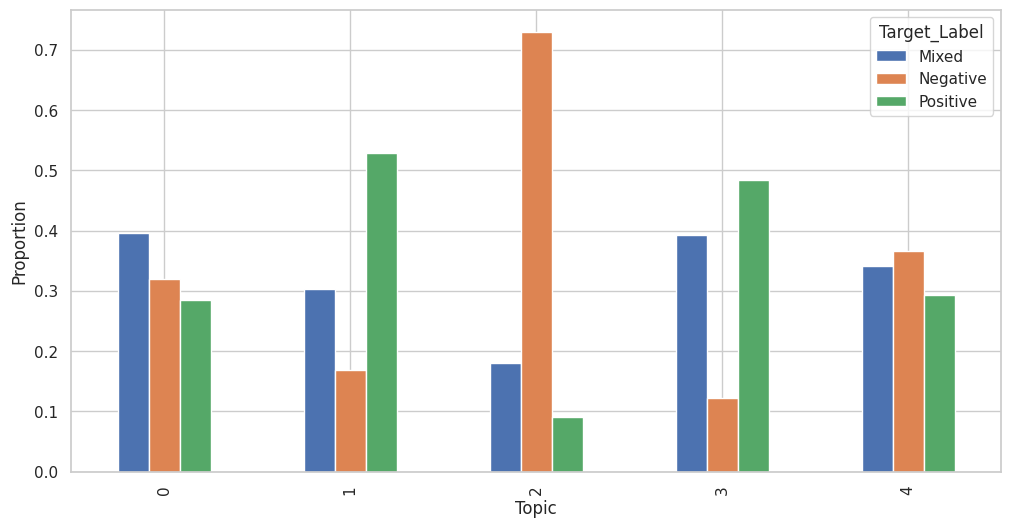

In [25]:
topic_target = df_analysis.groupby(["topic", "Target_Label"]).size().unstack(fill_value=0)
topic_target = topic_target.div(topic_target.sum(axis=1), axis=0)
topic_target.plot(kind="bar", figsize=(12,6))

plt.xlabel("Topic")
plt.ylabel("Proportion")

plt.savefig("target_per_topic.png", dpi=300, bbox_inches='tight')
plt.show()

In [26]:
sentiment_colors = {
    "Positive": "Greens",
    "Negative": "Reds",
    "Mixed":    "Blues"
}

print("Unique topics:", sorted(df_analysis["topic"].unique()))
print("Unique sentiments:", df_analysis["Target_Label"].unique())

Unique topics: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Unique sentiments: ['Negative' 'Positive' 'Mixed']


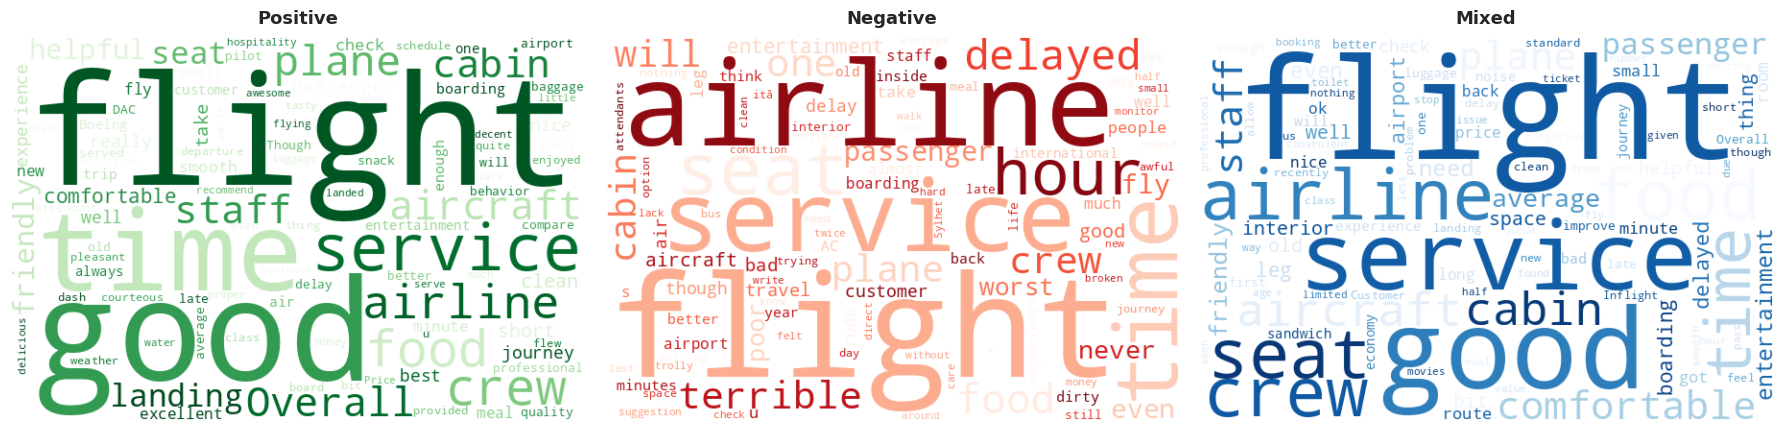

In [ ]:
topic_id = 0
topic_data = df_analysis[df_analysis["topic"] == topic_id]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, sentiment in zip(axes, ["Positive", "Negative", "Mixed"]):
    subset = topic_data[topic_data["Target_Label"] == sentiment]
    text = " ".join(subset["review"].astype(str).tolist())

    if len(text.strip()) == 0:
        ax.text(0.5, 0.5, "No Data", ha="center", va="center", fontsize=14)
        ax.axis("off")
        continue

    wc = WordCloud(
        width=600,
        height=400,
        background_color="white",
        colormap=sentiment_colors[sentiment],
        max_words=100,
        collocations=False
    ).generate(text)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{sentiment}", fontsize=13, fontweight="bold", pad=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"wordcloud_topic_{topic_id}.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
cluster_labels_short = {
    0: "Cluster-0",
    1: "Cluster-1",
    2: "Cluster-2",
    3: "Cluster-3",
    4: "Cluster-4"
}

def get_top_themes(df_clean, sentiment, n_themes=20, n_words=1):
    """Extract top TF-IDF terms per cluster for a given sentiment."""
    results = {}
    subset = df_clean[df_clean["Target_Label"] == sentiment]

    for tid in sorted(df_clean["topic"].unique()):
        cluster_text = subset[subset["topic"] == tid]["review"].astype(str).tolist()

        if len(cluster_text) < 3:
            results[tid] = ["N/A"] * n_themes
            continue

        tfidf = TfidfVectorizer(
            stop_words="english",
            max_features=500,
            ngram_range=(1, 2),
            min_df=1
        )
        try:
            tfidf.fit_transform(cluster_text)
            # Get top terms by mean TF-IDF score
            tfidf_matrix = tfidf.fit_transform(cluster_text).toarray()
            mean_scores  = tfidf_matrix.mean(axis=0)
            top_indices  = mean_scores.argsort()[::-1][:n_themes]
            vocab        = tfidf.get_feature_names_out()
            top_words    = [vocab[i].title() for i in top_indices]
            results[tid] = top_words
        except:
            results[tid] = ["N/A"] * n_themes

    return results

# Extract themes for all 3 sentiments
positive_themes = get_top_themes(df_analysis, "Positive", n_themes=20)
negative_themes = get_top_themes(df_analysis, "Negative", n_themes=20)
mixed_themes    = get_top_themes(df_analysis, "Mixed",    n_themes=20)

print("Themes extracted ✓")

Themes extracted ✓


In [28]:
def build_theme_table(themes_dict, n_themes=20):
    """Convert themes dict to a styled DataFrame."""
    df_table = pd.DataFrame(
        {cluster_labels_short[tid]: themes_dict[tid] for tid in sorted(themes_dict.keys())}
    )
    df_table.index = [f"Theme-{i+1}" for i in range(n_themes)]
    df_table.index.name = None
    return df_table

df_positive = build_theme_table(positive_themes)
df_negative = build_theme_table(negative_themes)
df_mixed    = build_theme_table(mixed_themes)

print("Positive Themes Table:")
print(df_positive)
print("\nNegative Themes Table:")
print(df_negative)
print("\nMixed Themes Table:")
print(df_mixed)

Positive Themes Table:
             Cluster-0   Cluster-1            Cluster-2            Cluster-3  \
Theme-1           Good      Flight               Flight                Biman   
Theme-2         Flight        Good                Biman               Flight   
Theme-3           Time       Dhaka                 Time                 Good   
Theme-4        Service        Time                Dhaka           Bangladesh   
Theme-5           Food     Service              Service              Service   
Theme-6           Crew    Airlines                Plane             Airlines   
Theme-7        Overall      Regent           Bangladesh     Biman Bangladesh   
Theme-8          Plane        Food             Airlines                 Time   
Theme-9       Friendly  Chittagong     Biman Bangladesh              Airline   
Theme-10         Cabin      Bangla             Aircraft                Dhaka   
Theme-11       Helpful     Airline                 Good                 Food   
Theme-12       Ai

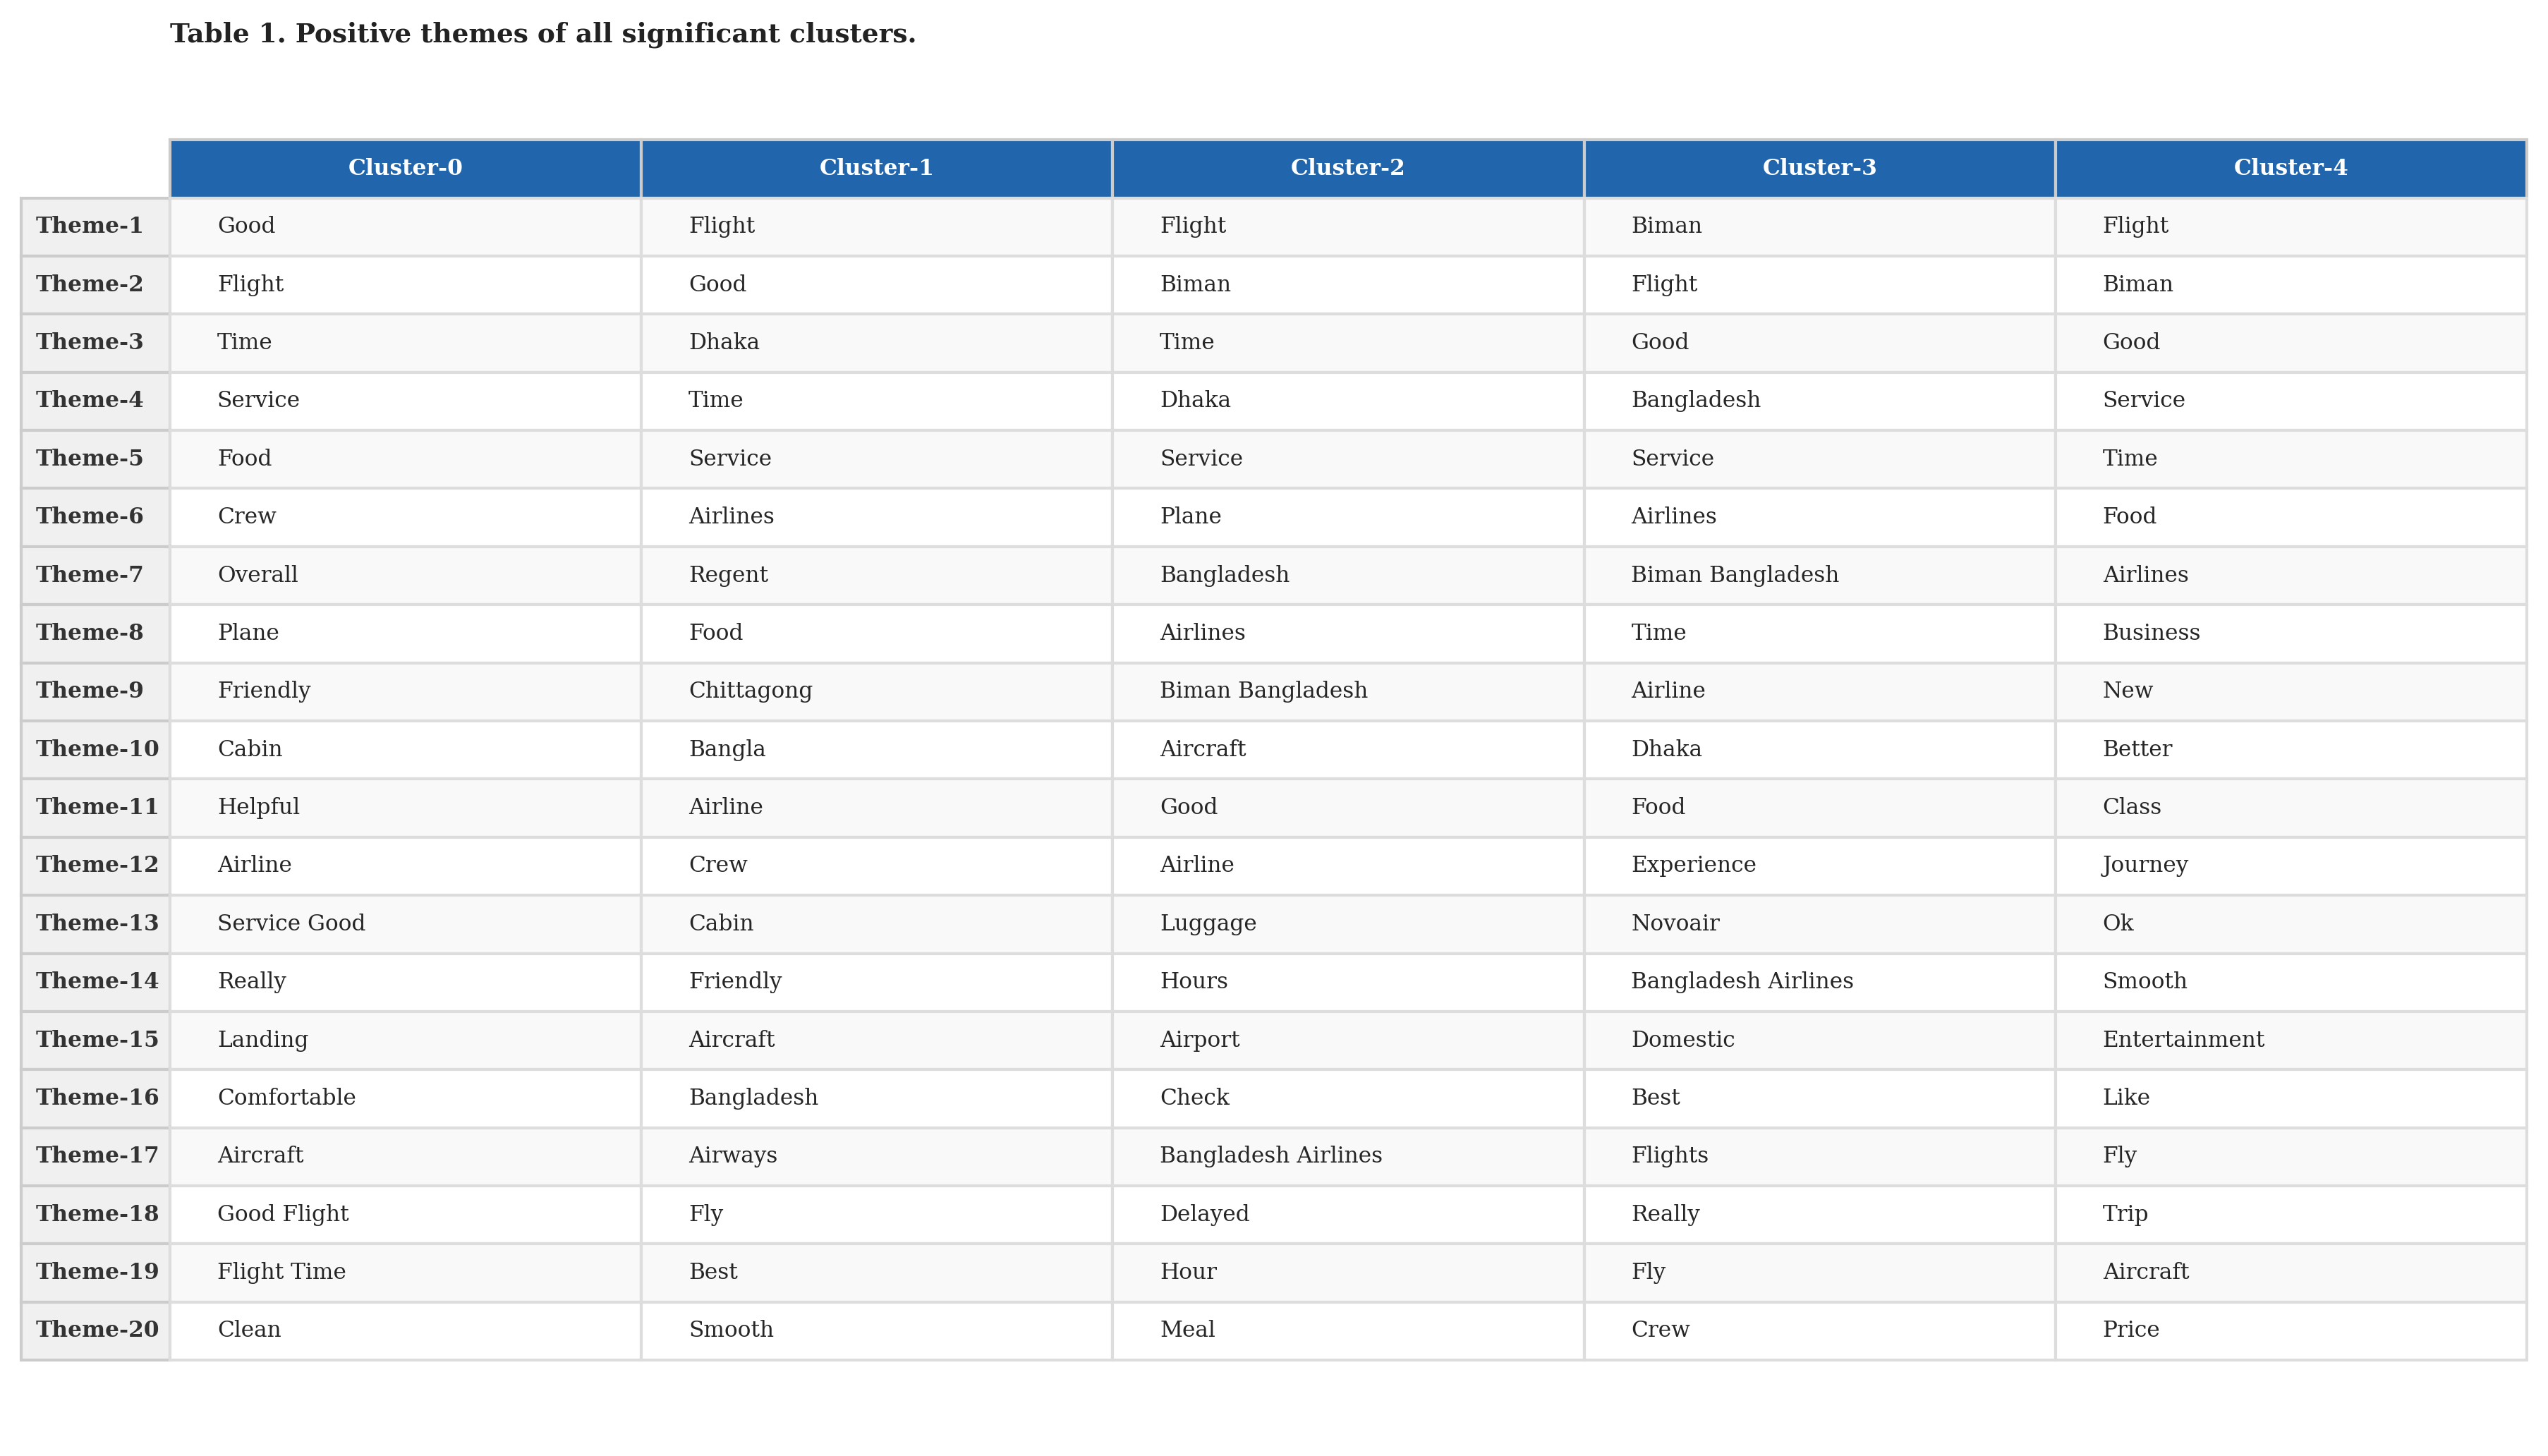

table_positive_themes saved ✓


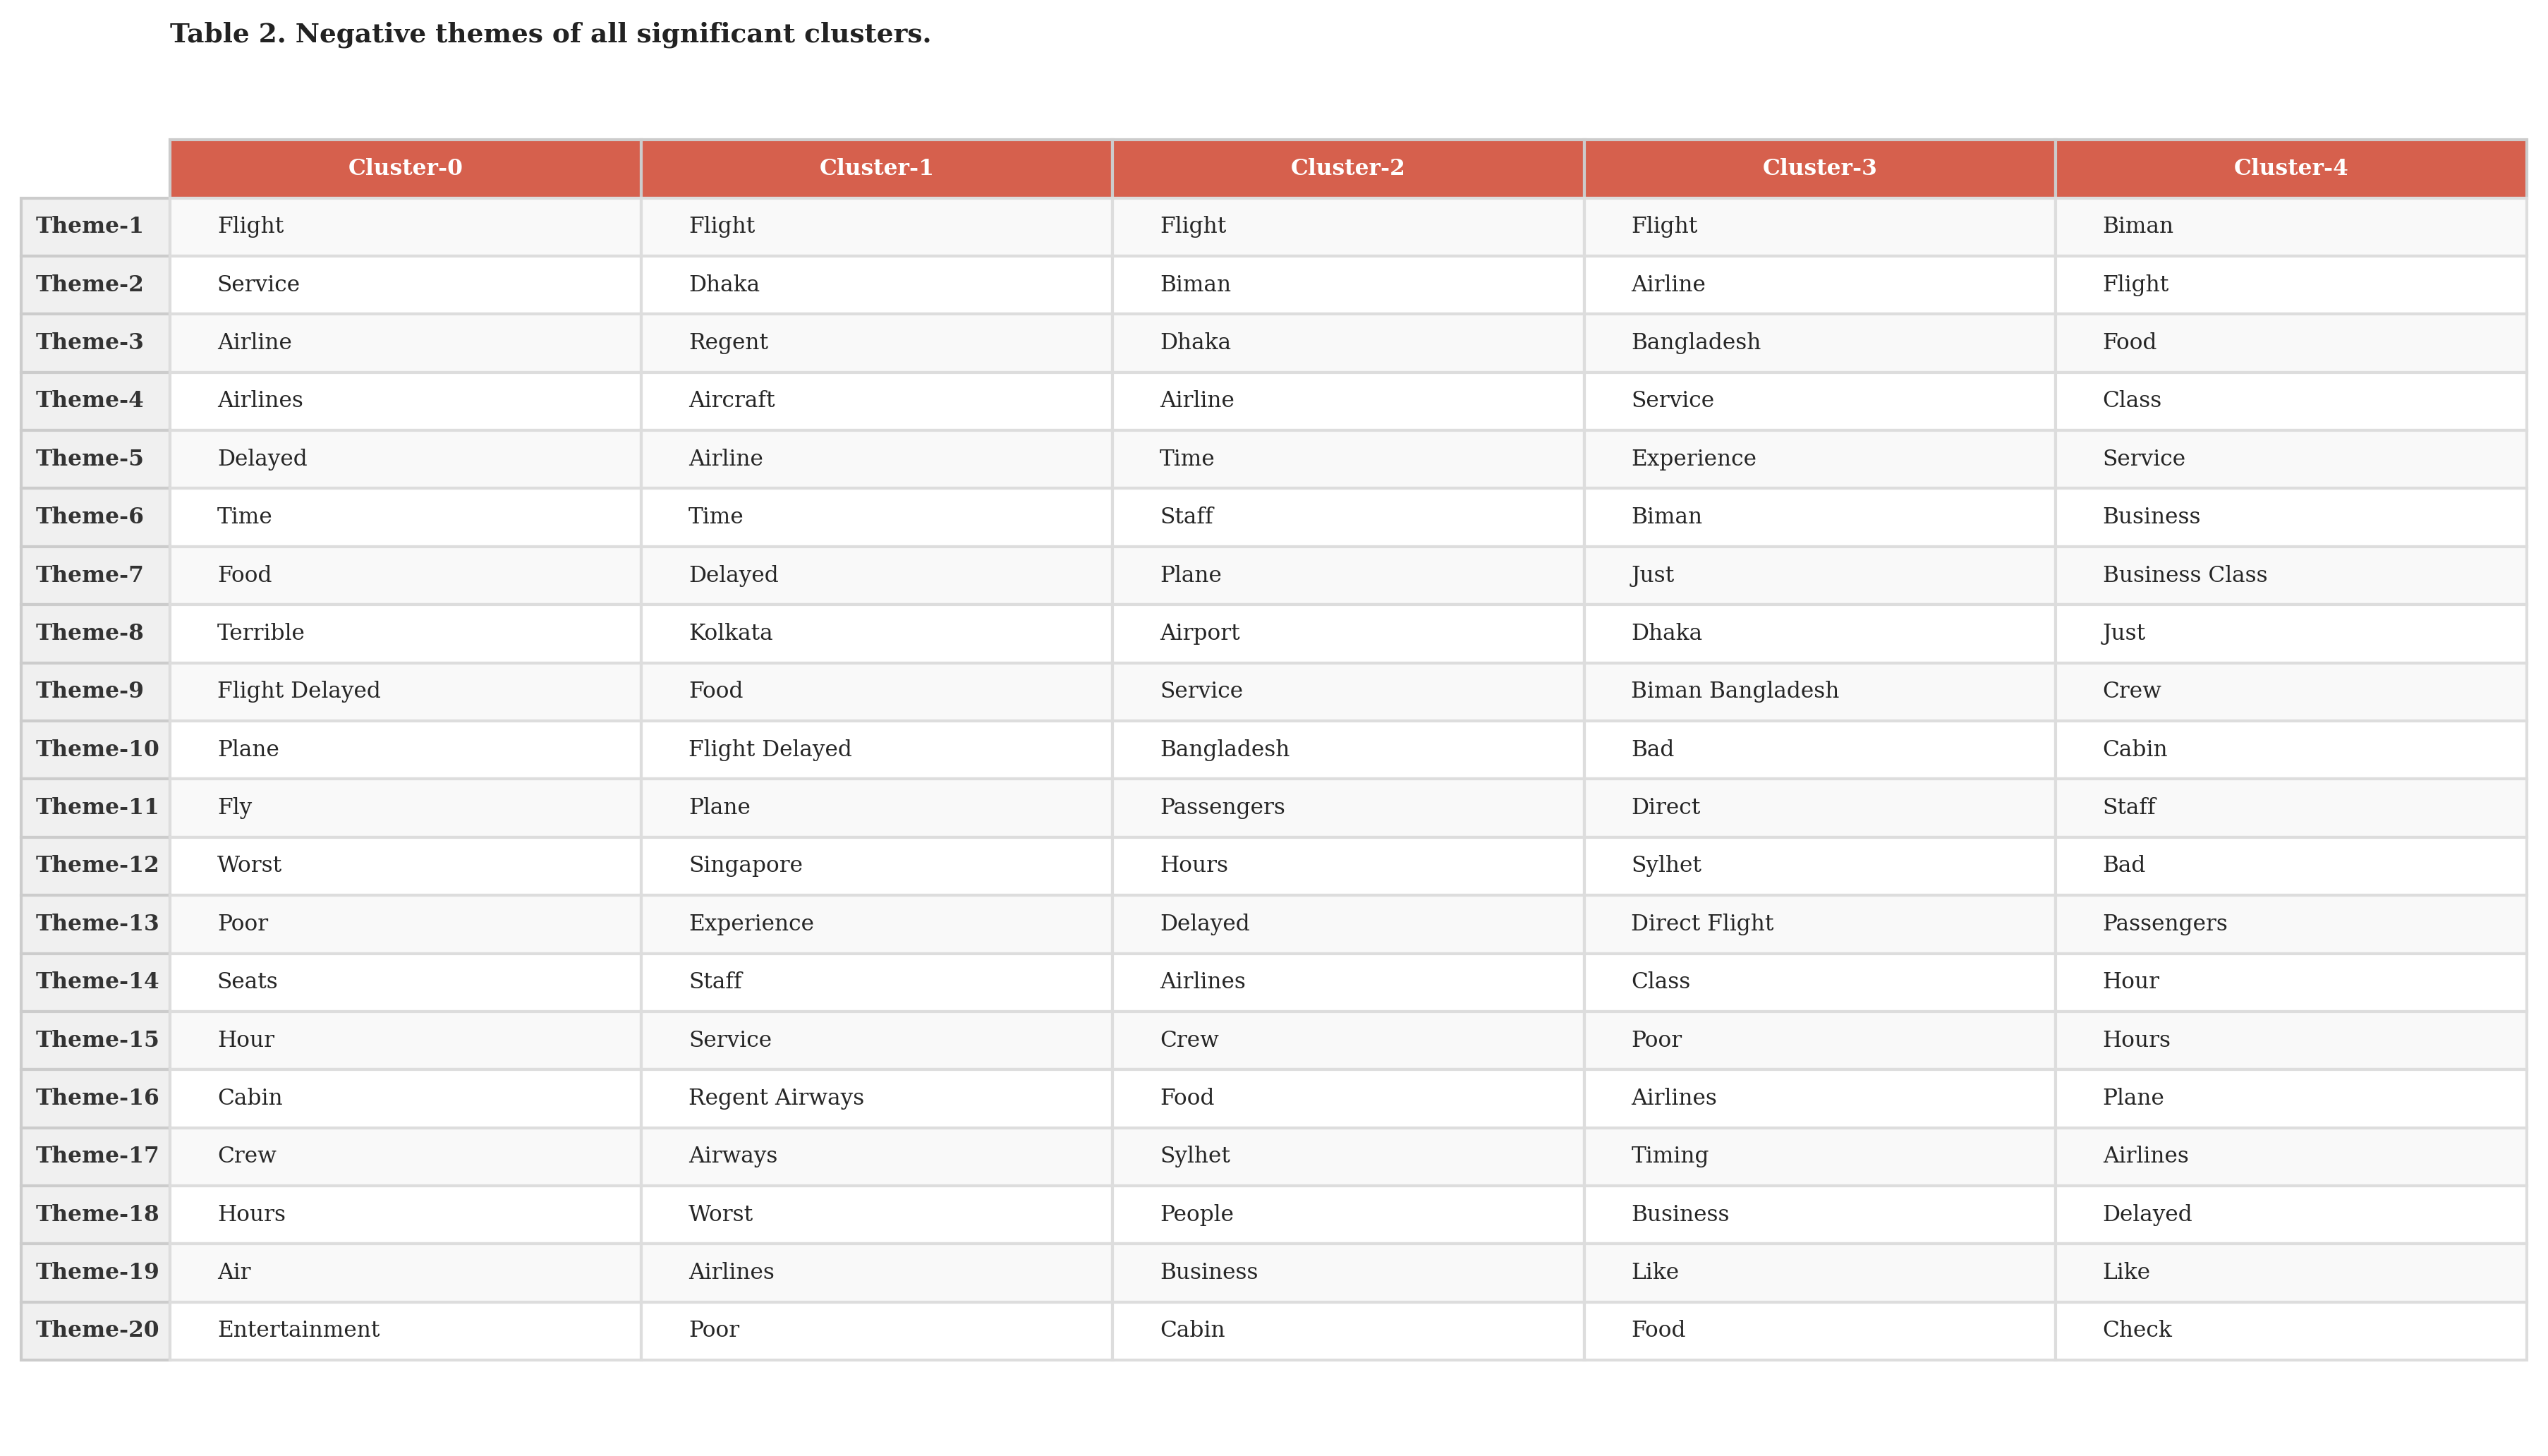

table_negative_themes saved ✓


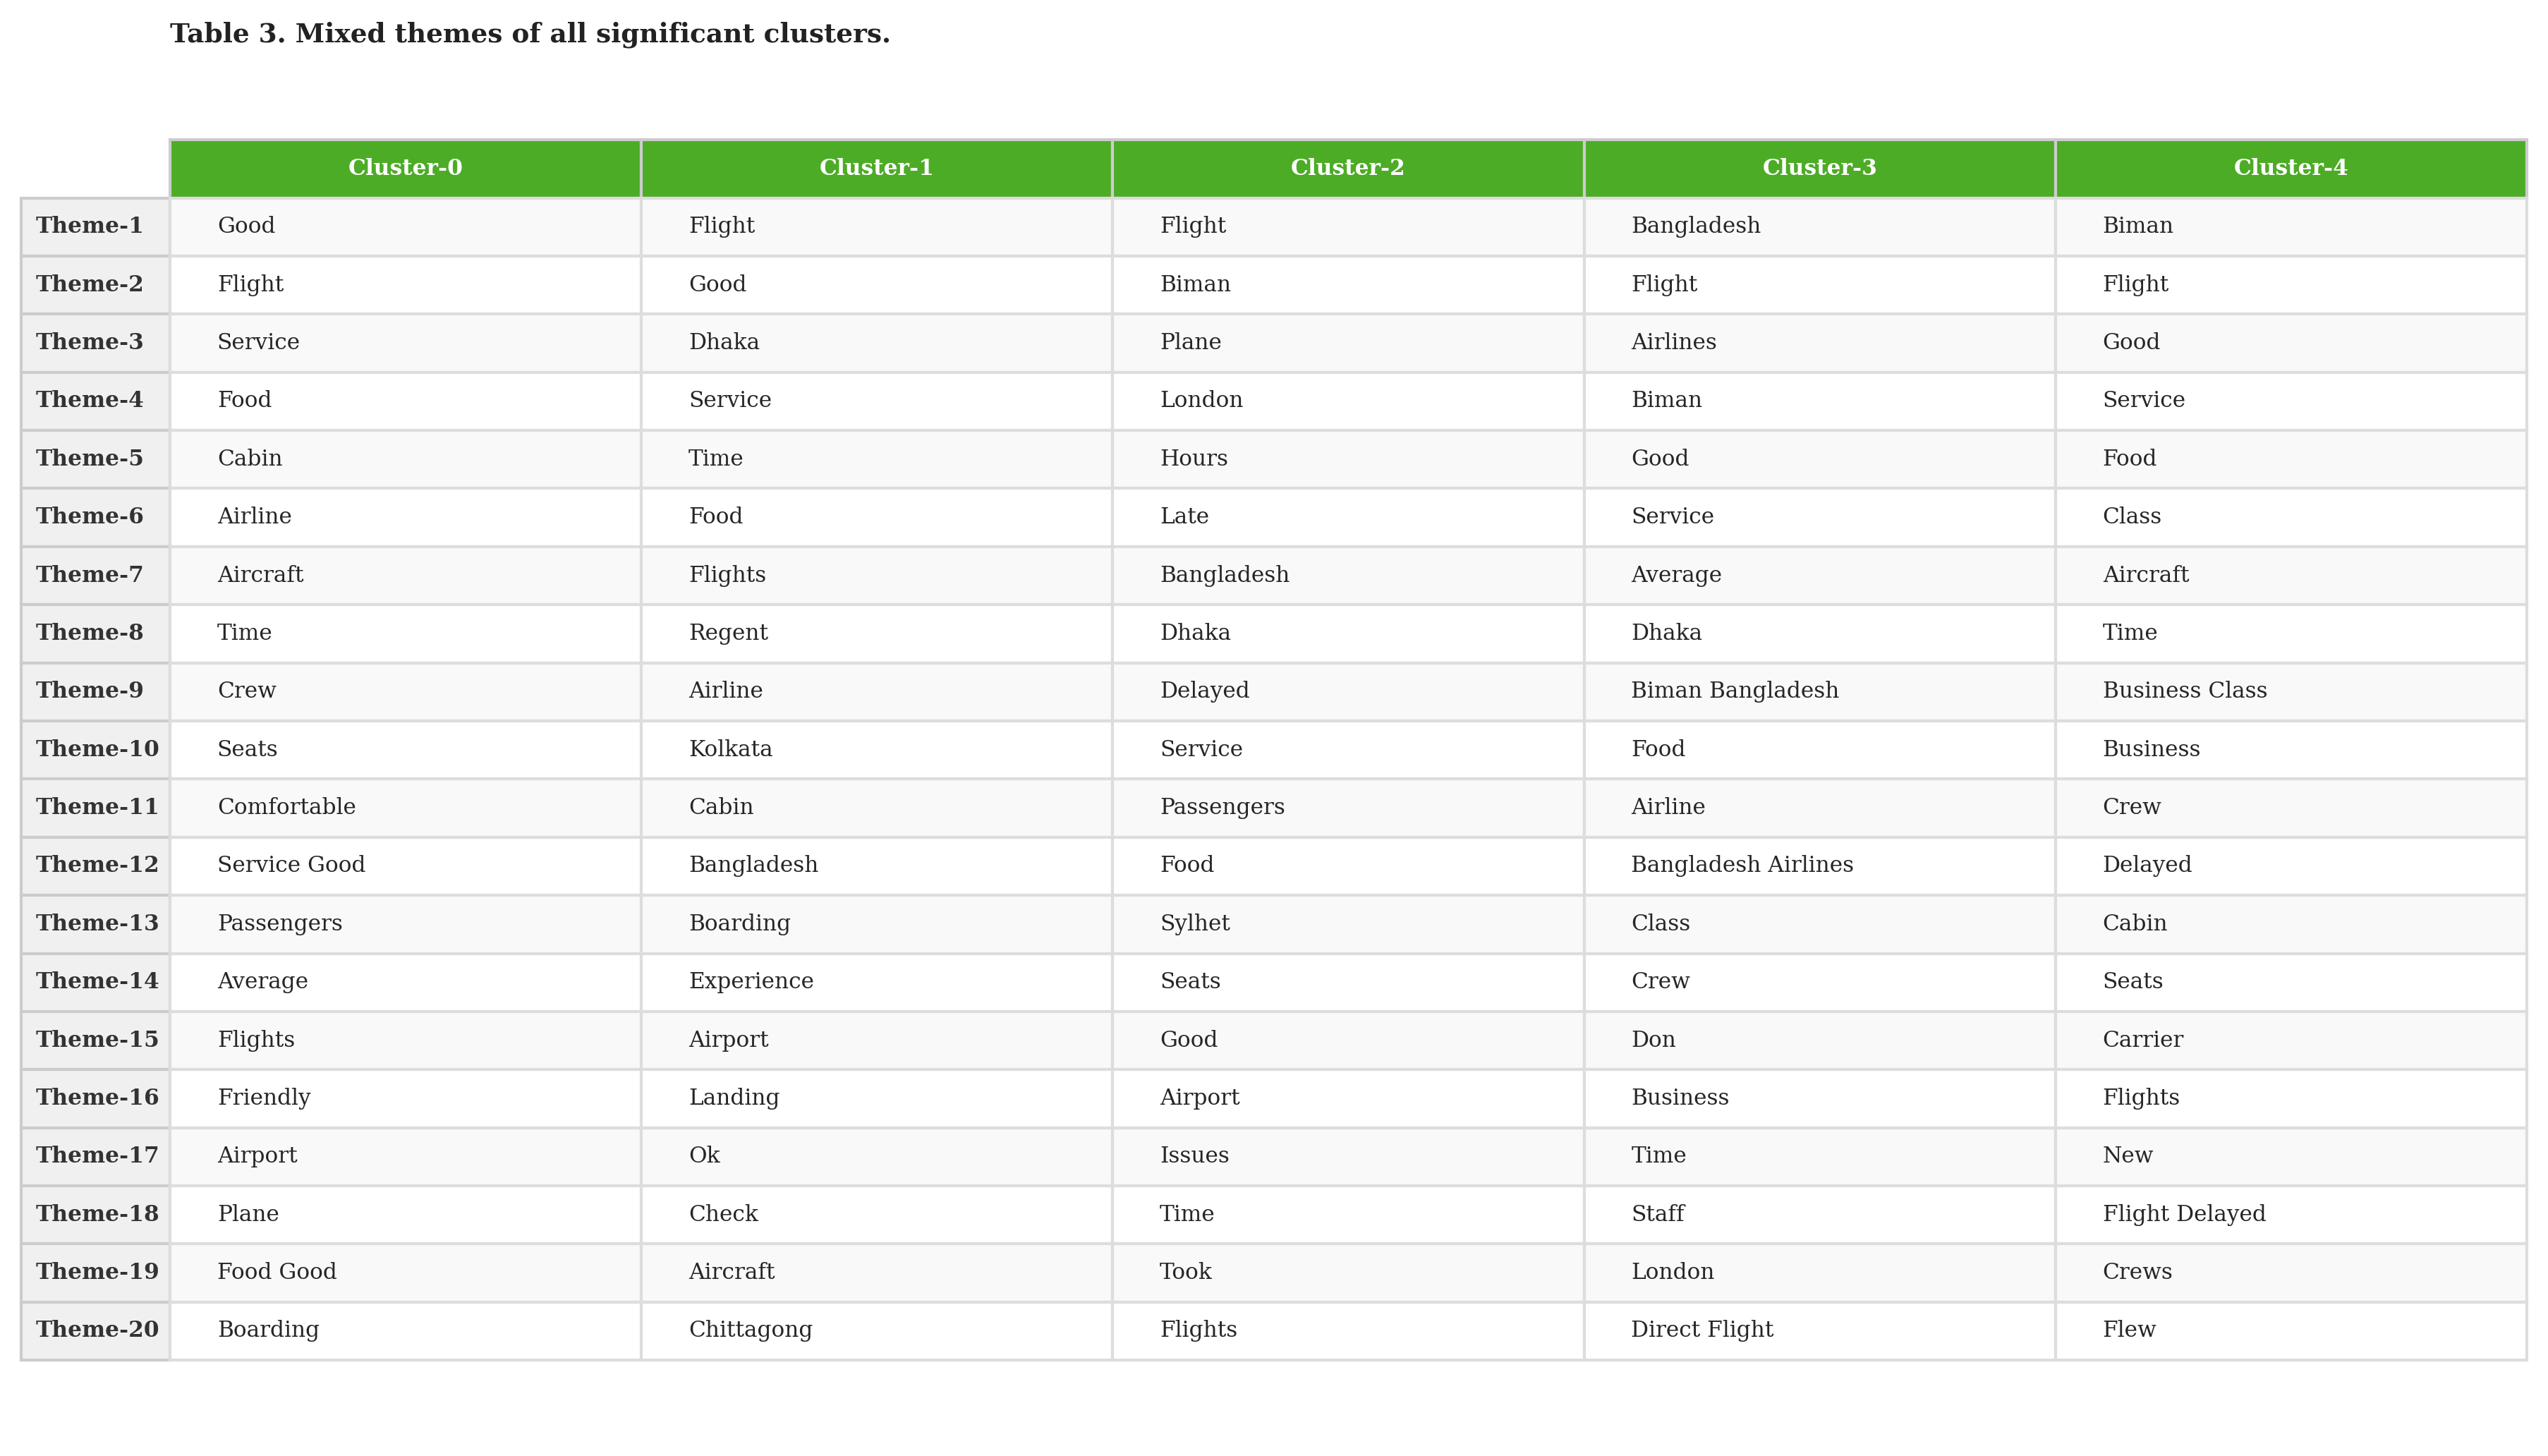

table_mixed_themes saved ✓


In [29]:
mpl.rcParams.update({
    "font.family":  "serif",
    "font.serif":   ["Times New Roman", "DejaVu Serif"],
    "figure.dpi":   300,
    "savefig.dpi":  300,
})

def plot_journal_table(df_table, title, filename, header_color="#2166AC"):
    n_rows, n_cols = df_table.shape
    fig_h = 0.32 * (n_rows + 2)
    fig_w = 2.2  * n_cols + 1.2

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    cell_text   = df_table.values.tolist()
    row_labels  = list(df_table.index)
    col_labels  = list(df_table.columns)

    table = ax.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc="left",
        rowLoc="left",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(7.5)
    table.scale(1, 1.38)

    for col_idx in range(n_cols):
        cell = table[0, col_idx]
        cell.set_facecolor(header_color)
        cell.set_text_props(color="white", fontweight="bold")
        cell.set_edgecolor("#cccccc")

    for row_idx in range(1, n_rows + 1):
        cell = table[row_idx, -1]
        cell.set_facecolor("#f0f0f0")
        cell.set_text_props(fontweight="bold", color="#333333")
        cell.set_edgecolor("#cccccc")

    for row_idx in range(1, n_rows + 1):
        for col_idx in range(n_cols):
            cell = table[row_idx, col_idx]
            cell.set_facecolor("#ffffff" if row_idx % 2 == 0 else "#f9f9f9")
            cell.set_edgecolor("#dddddd")

    ax.set_title(title, fontsize=9, fontweight="bold",
                 loc="left", pad=8, color="#222222")

    plt.tight_layout()
    plt.savefig(f"{filename}.pdf", bbox_inches="tight")
    plt.savefig(f"{filename}.png", bbox_inches="tight")
    plt.show()
    print(f"{filename} saved ✓")

plot_journal_table(
    df_positive,
    title="Table 1. Positive themes of all significant clusters.",
    filename="table_positive_themes",
    header_color="#2166AC"
)

plot_journal_table(
    df_negative,
    title="Table 2. Negative themes of all significant clusters.",
    filename="table_negative_themes",
    header_color="#D6604D"
)

plot_journal_table(
    df_mixed,
    title="Table 3. Mixed themes of all significant clusters.",
    filename="table_mixed_themes",
    header_color="#4DAC26"
)

In [30]:
df_positive.to_csv("positive_themes.csv")
df_negative.to_csv("negative_themes.csv")
df_mixed.to_csv("mixed_themes.csv")

print("CSVs saved ✓")

CSVs saved ✓


In [31]:
dominant = df_analysis.groupby("topic")["Target_Label"] \
                      .agg(lambda x: x.value_counts().index[0])

print("Dominant Sentiment per Topic:\n")
print(dominant)

Dominant Sentiment per Topic:

topic
0       Mixed
1    Positive
2    Negative
3    Positive
4    Negative
Name: Target_Label, dtype: object


In [33]:
table = pivot # Use the 'pivot' DataFrame already computed
table.to_csv("topic_target_table.csv")
print(table)

Target_Label     Mixed  Negative  Positive
topic                                     
0             0.395664  0.319783  0.284553
1             0.303738  0.168224  0.528037
2             0.179775  0.730337  0.089888
3             0.392638  0.122699  0.484663
4             0.341463  0.365854  0.292683


In [34]:
encoder = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = encoder.encode(texts, show_progress_bar=True, batch_size=64)

df["topic"] = topics
df["text"]  = texts
df_clean = df[df["topic"] != -1].reset_index(drop=True)

# TF-IDF
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=150,
    ngram_range=(1, 2),
    min_df=5
)
X = tfidf.fit_transform(df_clean["text"].astype(str)).toarray()
feature_names = tfidf.get_feature_names_out()

# Encode sentiment
le = LabelEncoder()
y_sentiment = le.fit_transform(df_clean["Target_Label"])
sentiment_names = le.classes_

print("Setup done. Sentiment classes:", sentiment_names)
print("Embeddings shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/17 [00:00<?, ?it/s]

Setup done. Sentiment classes: ['Mixed' 'Negative' 'Positive']
Embeddings shape: (1047, 384)


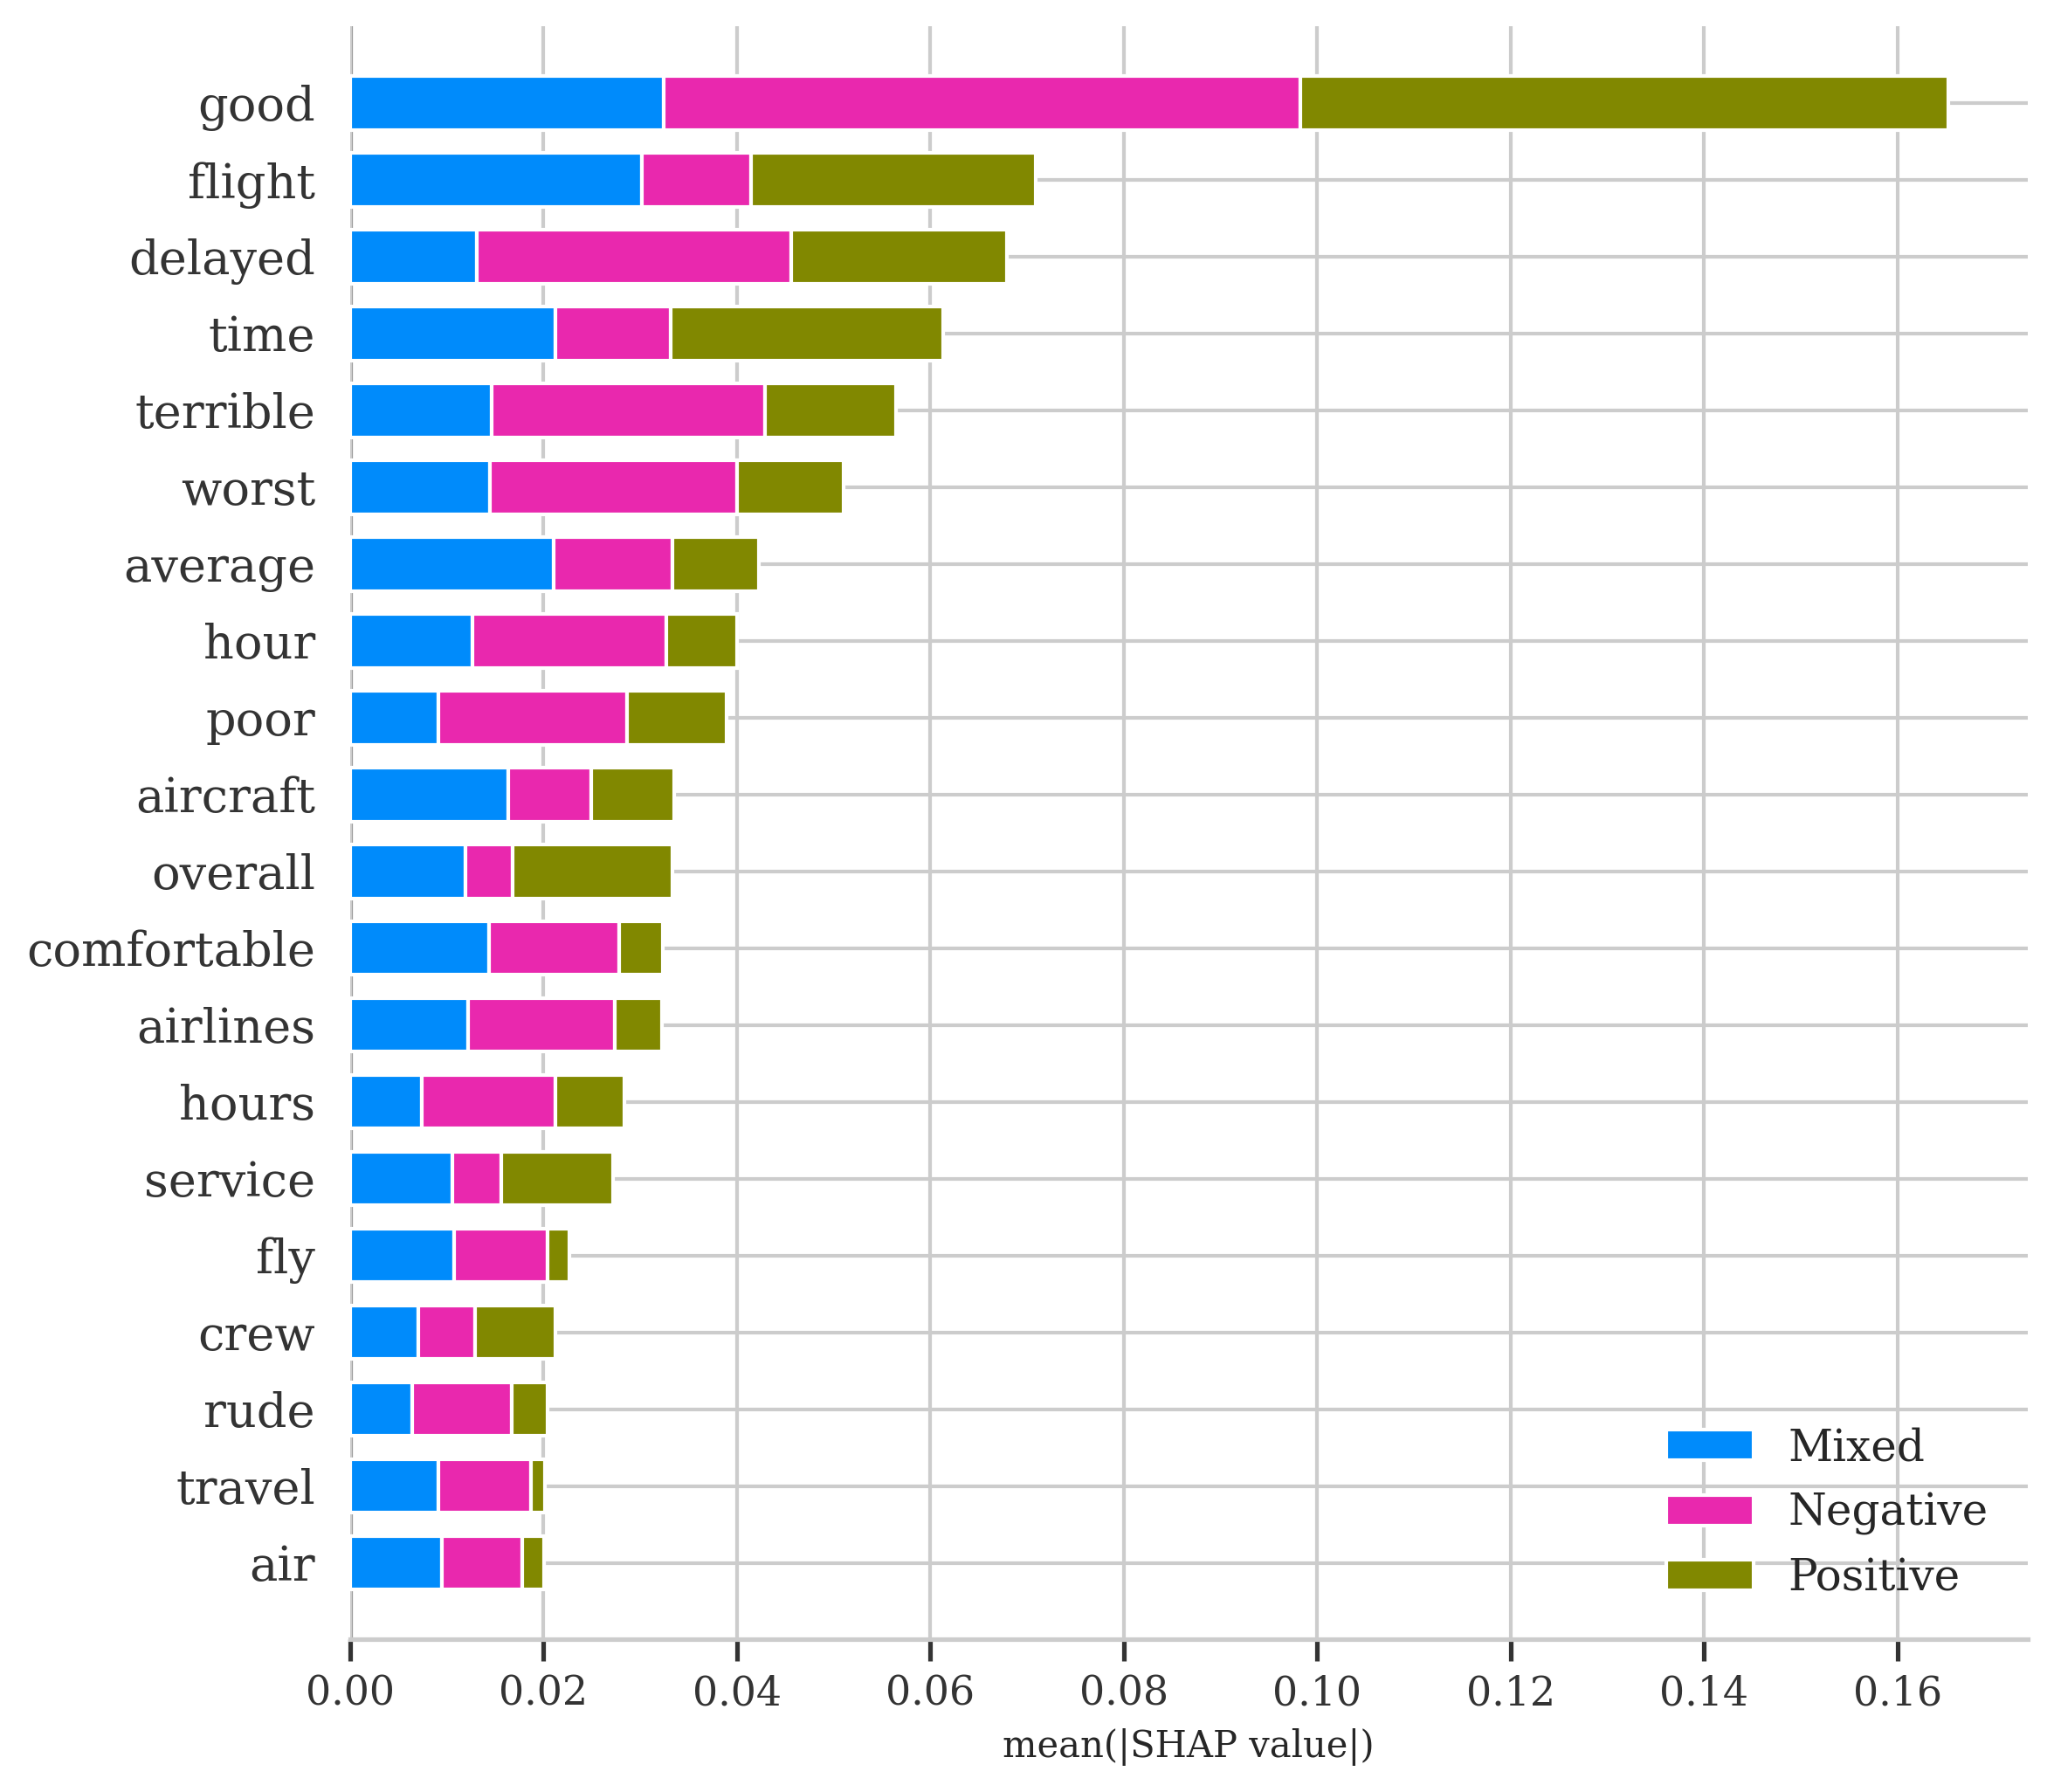

In [35]:
topic_id = 0
topic_mask = df_clean["topic"] == topic_id
X_topic = X[topic_mask]
y_topic = y_sentiment[topic_mask]

clf_topic = RandomForestClassifier(n_estimators=135, random_state=50)
clf_topic.fit(X_topic, y_topic)

explainer_topic = shap.TreeExplainer(clf_topic)
shap_values_topic = explainer_topic.shap_values(X_topic)

fig, ax = plt.subplots(figsize=(8, 7))
plt.sca(ax)
shap.summary_plot(
    shap_values_topic,
    X_topic,
    feature_names=feature_names,
    class_names=list(sentiment_names),
    show=False,
    max_display=20,
    plot_size=None,
    plot_type="bar"
)
ax.set_title("")
ax.set_xlabel("mean(|SHAP value|)", fontsize=10)
plt.tight_layout()
plt.savefig("shap_topic_0.png", dpi=150, bbox_inches="tight")
plt.show()

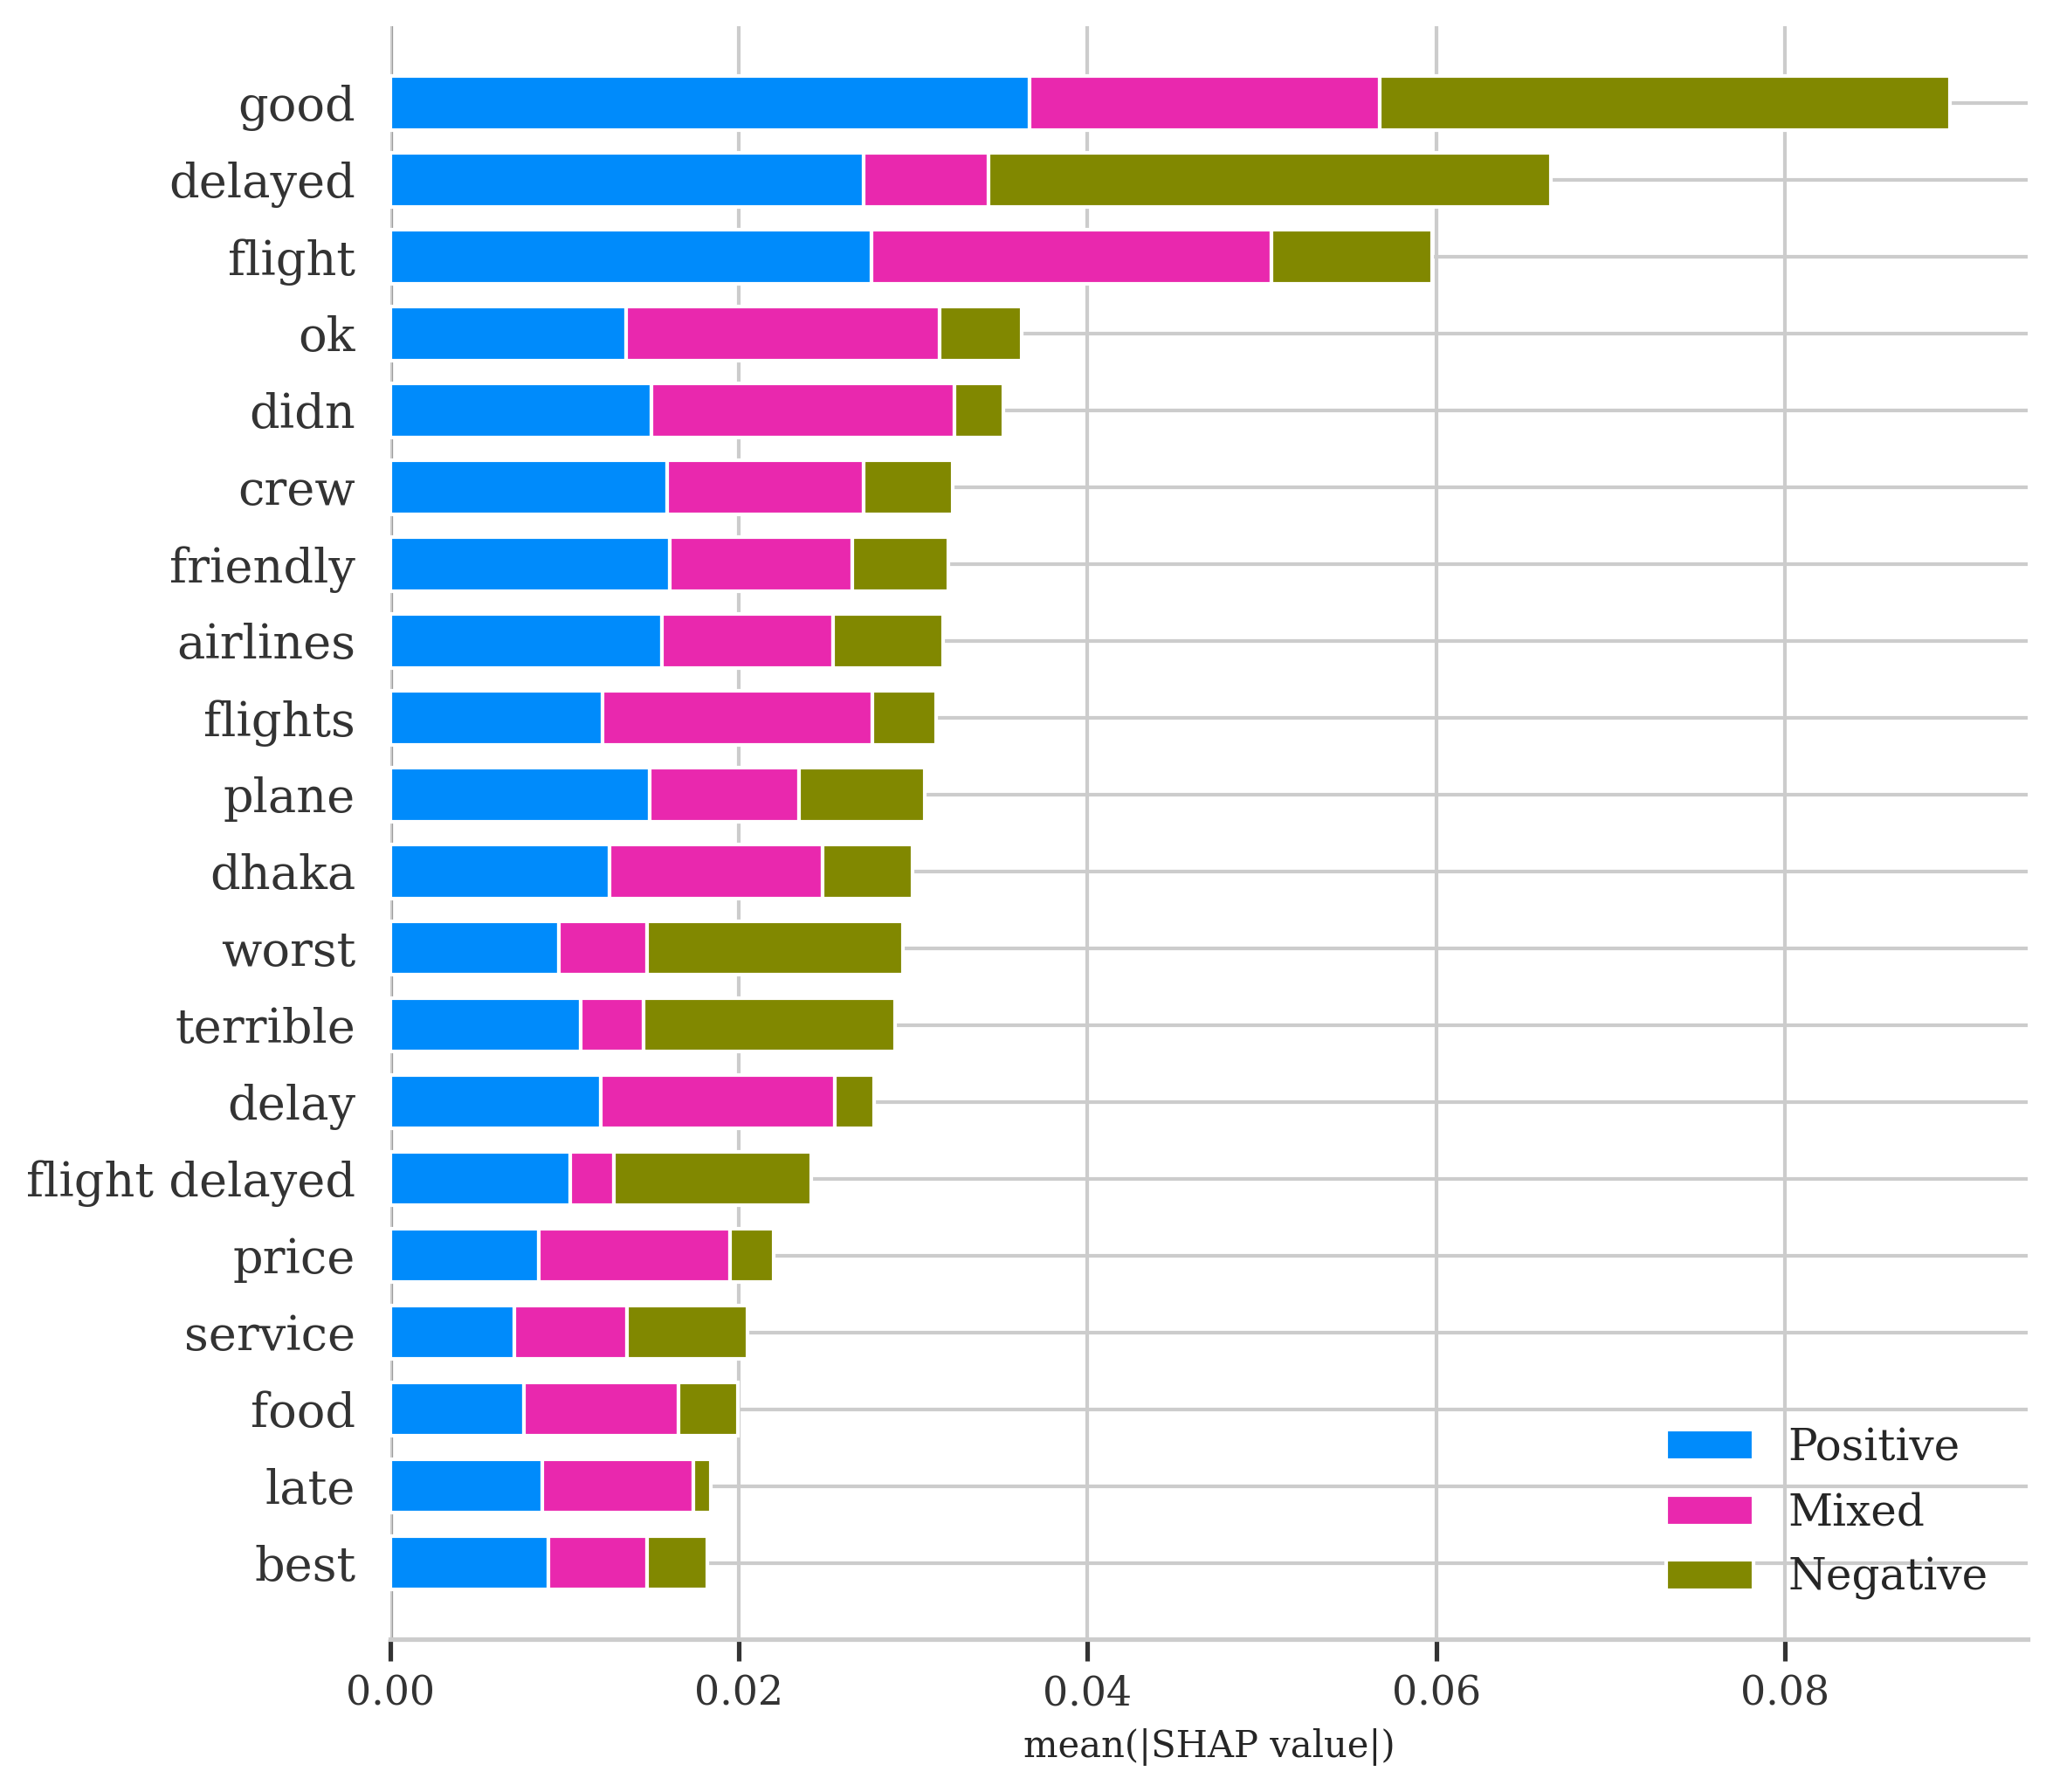

In [36]:
topic_id = 1
topic_mask = df_clean["topic"] == topic_id
X_topic = X[topic_mask]
y_topic = y_sentiment[topic_mask]

clf_topic = RandomForestClassifier(n_estimators=135, random_state=50)
clf_topic.fit(X_topic, y_topic)

explainer_topic = shap.TreeExplainer(clf_topic)
shap_values_topic = explainer_topic.shap_values(X_topic)

fig, ax = plt.subplots(figsize=(8, 7))
plt.sca(ax)
shap.summary_plot(
    shap_values_topic,
    X_topic,
    feature_names=feature_names,
    class_names=list(sentiment_names),
    show=False,
    max_display=20,
    plot_size=None,
    plot_type="bar"
)
ax.set_title("")
ax.set_xlabel("mean(|SHAP value|)", fontsize=10)
plt.tight_layout()
plt.savefig("shap_topic_1.png", dpi=150, bbox_inches="tight")
plt.show()

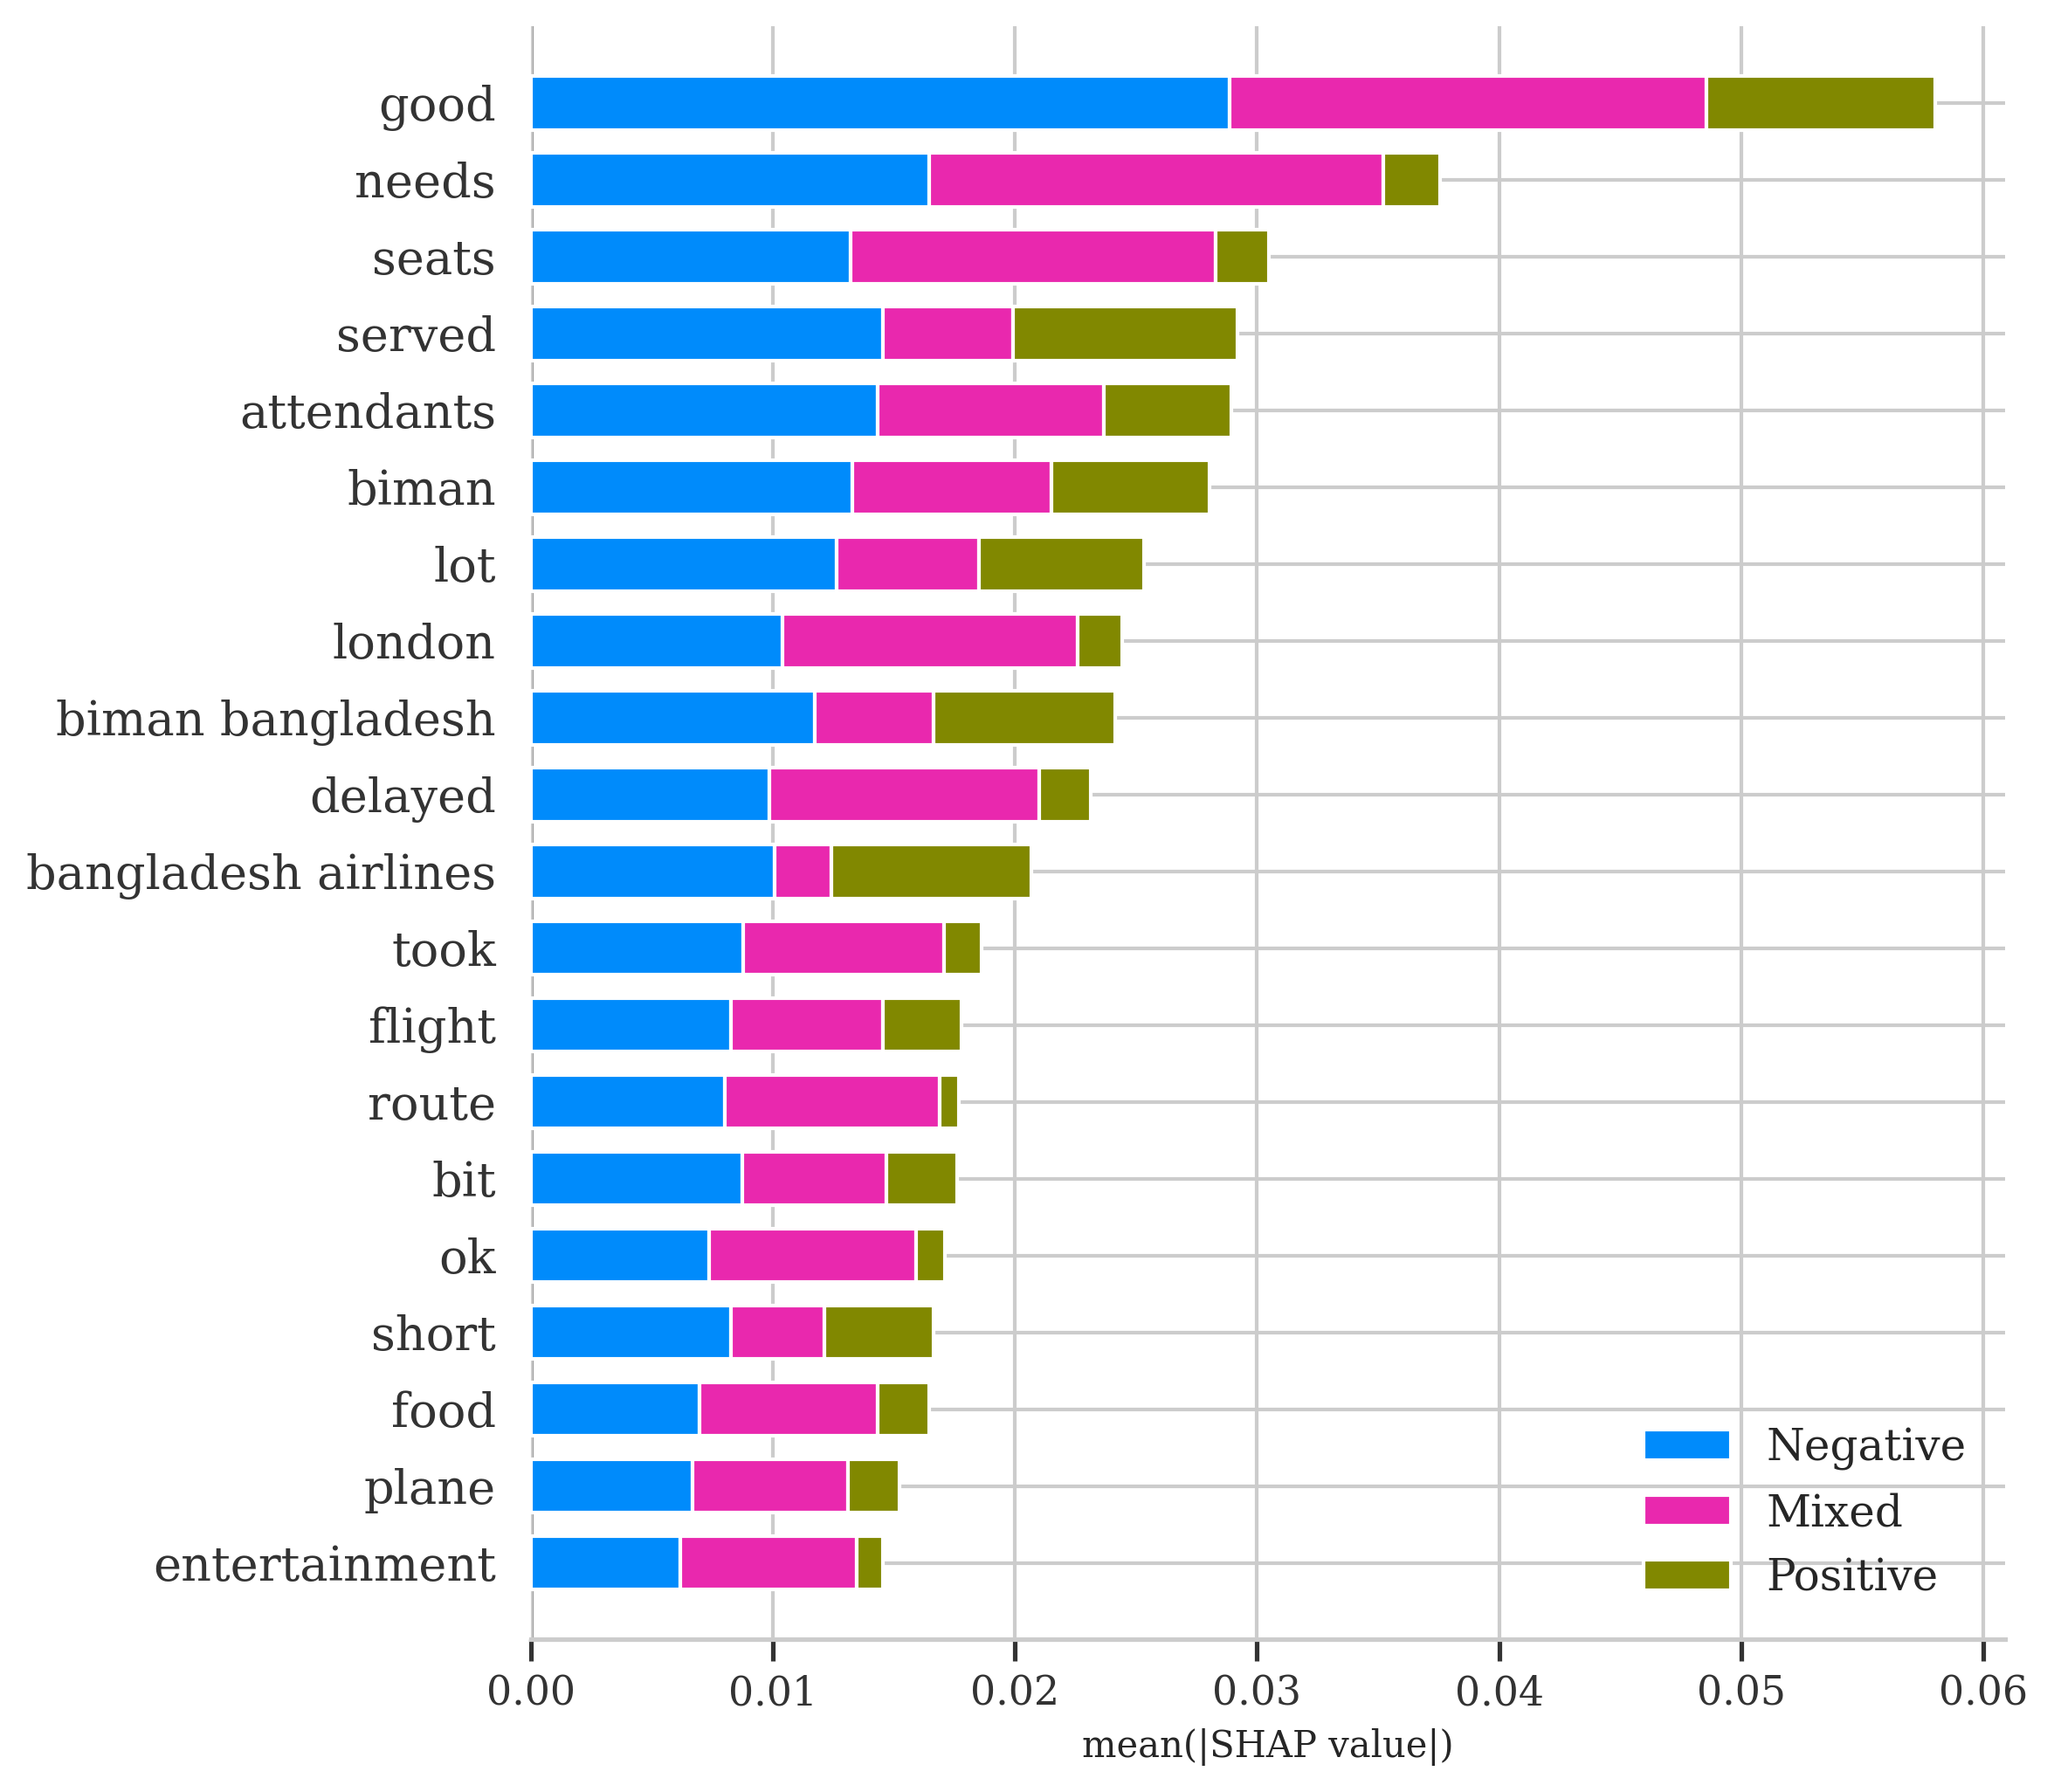

In [37]:
topic_id = 2
topic_mask = df_clean["topic"] == topic_id
X_topic = X[topic_mask]
y_topic = y_sentiment[topic_mask]

clf_topic = RandomForestClassifier(n_estimators=135, random_state=50)
clf_topic.fit(X_topic, y_topic)

explainer_topic = shap.TreeExplainer(clf_topic)
shap_values_topic = explainer_topic.shap_values(X_topic)

fig, ax = plt.subplots(figsize=(8, 7))
plt.sca(ax)
shap.summary_plot(
    shap_values_topic,
    X_topic,
    feature_names=feature_names,
    class_names=list(sentiment_names),
    show=False,
    max_display=20,
    plot_size=None,
    plot_type="bar"
)
ax.set_title("")
ax.set_xlabel("mean(|SHAP value|)", fontsize=10)
plt.tight_layout()
plt.savefig("shap_topic_2.png", dpi=150, bbox_inches="tight")
plt.show()

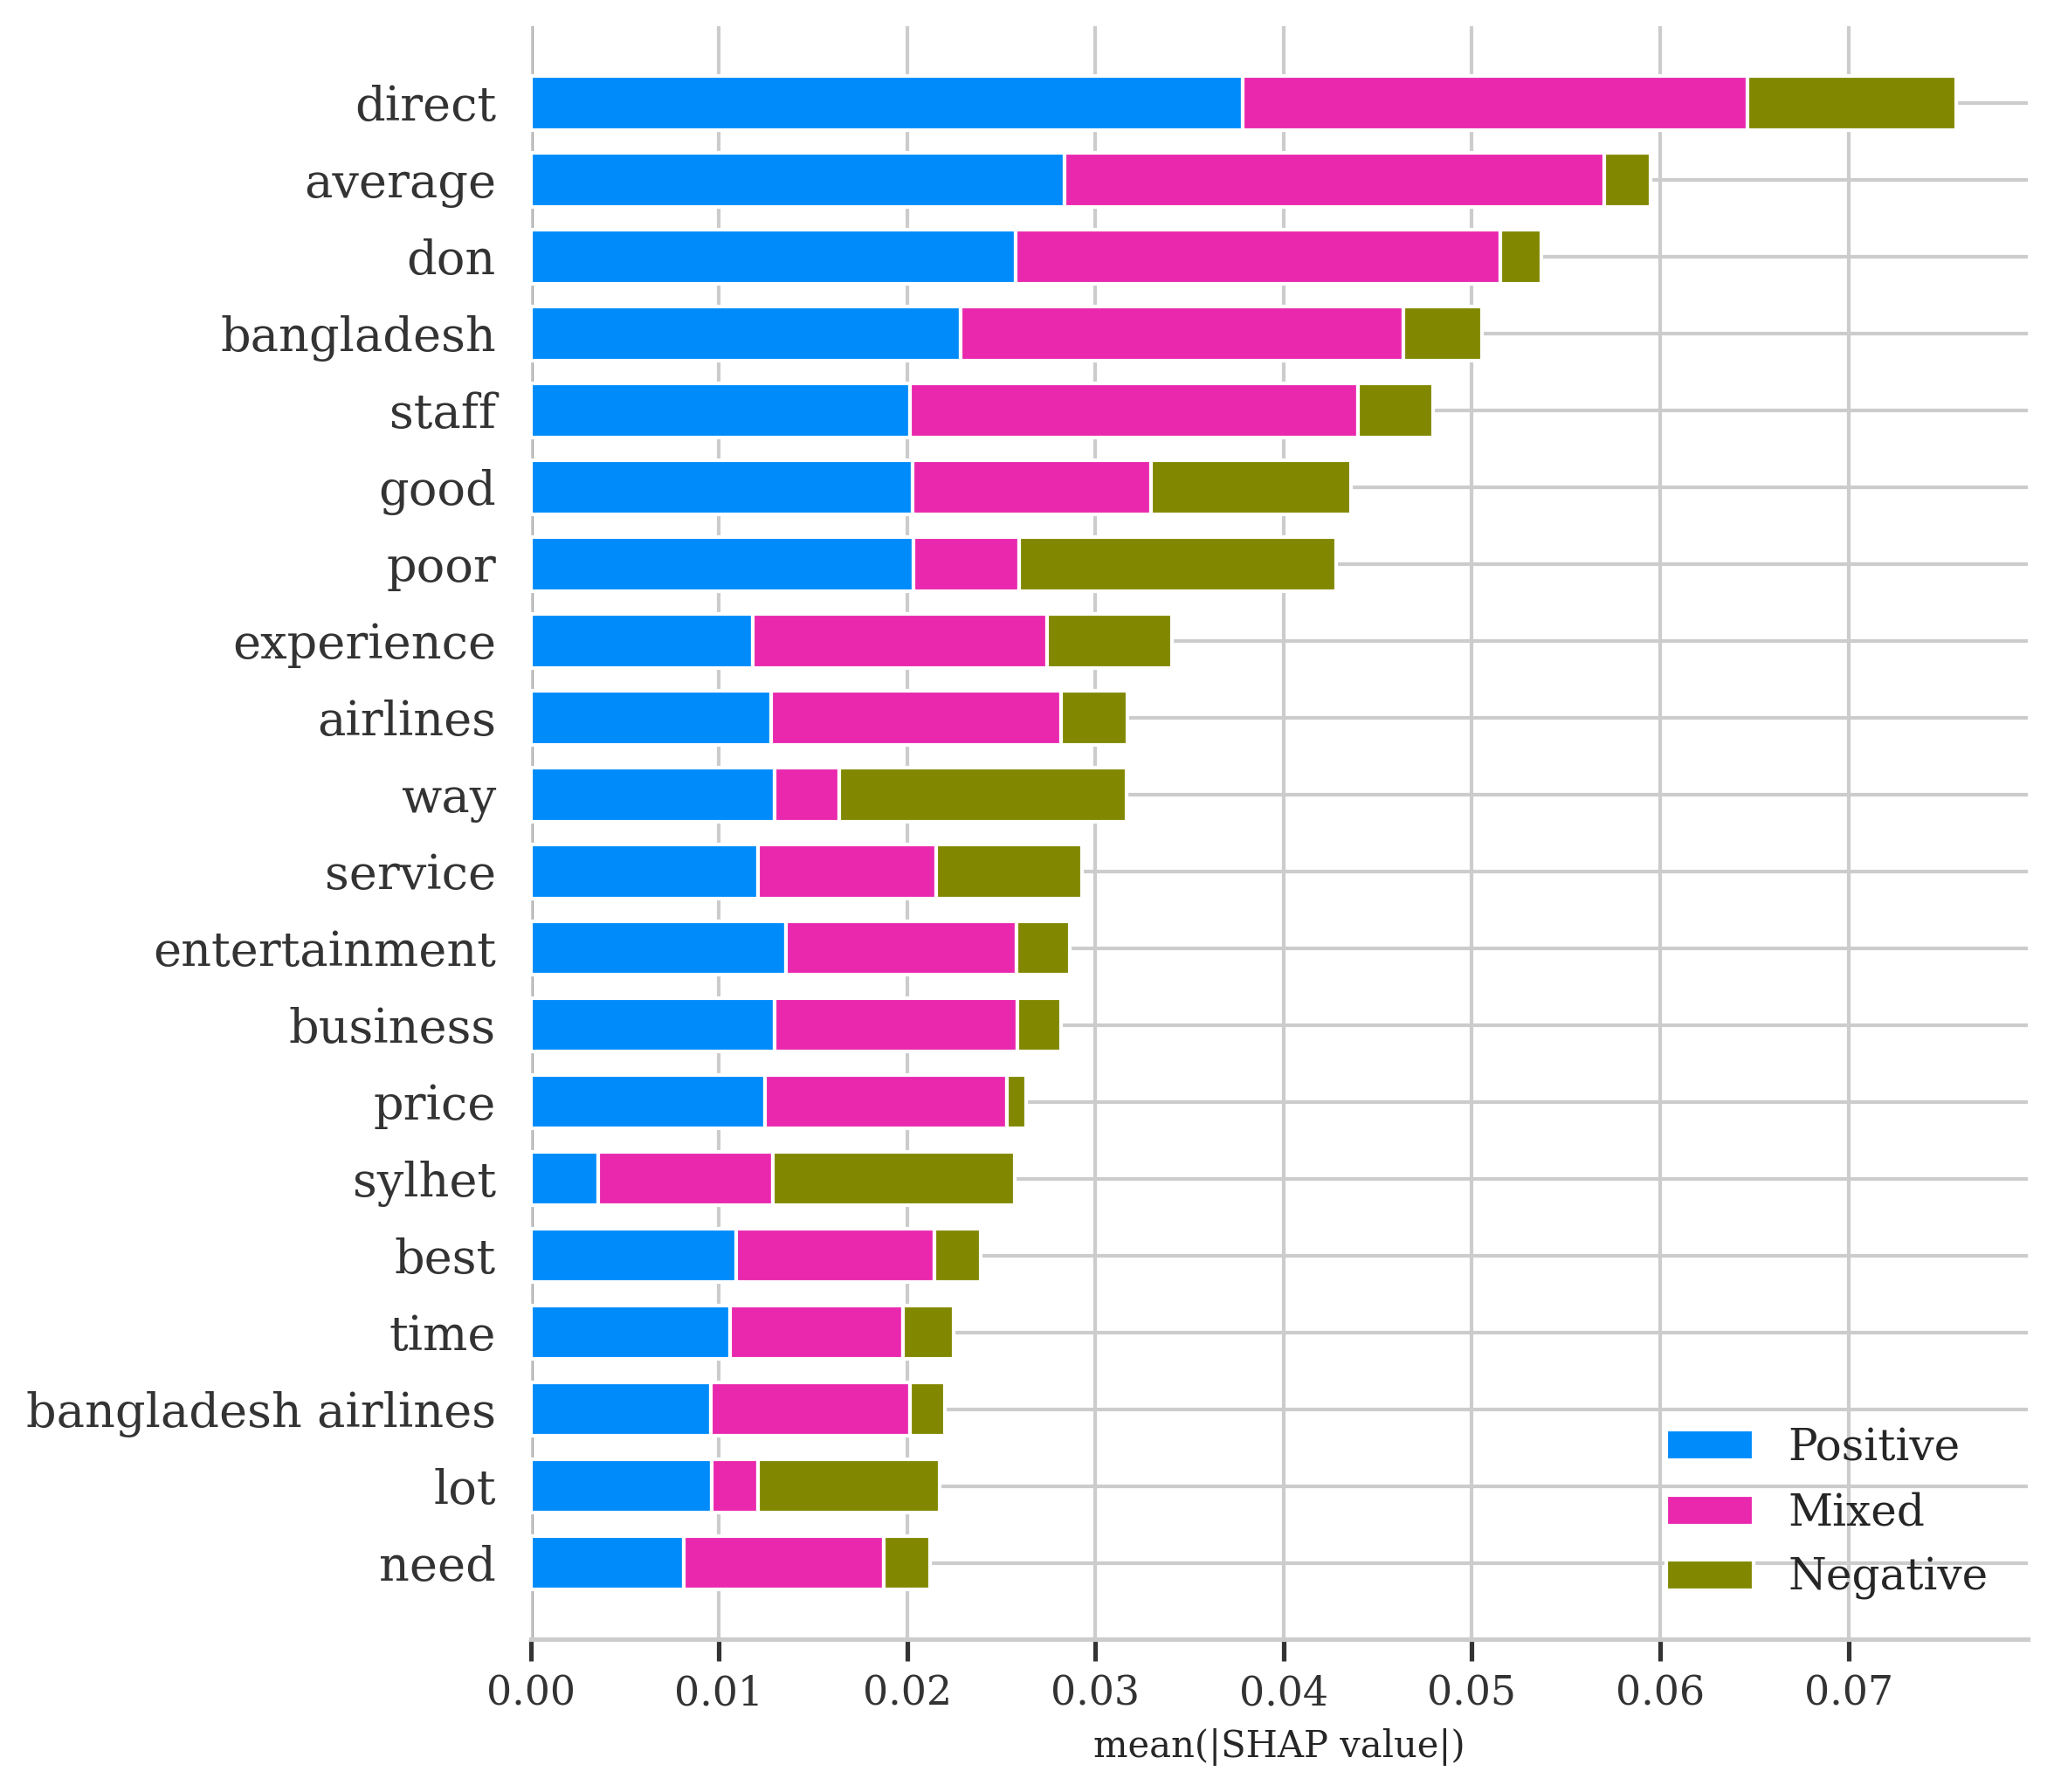

In [38]:
topic_id = 3
topic_mask = df_clean["topic"] == topic_id
X_topic = X[topic_mask]
y_topic = y_sentiment[topic_mask]

clf_topic = RandomForestClassifier(n_estimators=135, random_state=50)
clf_topic.fit(X_topic, y_topic)

explainer_topic = shap.TreeExplainer(clf_topic)
shap_values_topic = explainer_topic.shap_values(X_topic)

fig, ax = plt.subplots(figsize=(8, 7))
plt.sca(ax)
shap.summary_plot(
    shap_values_topic,
    X_topic,
    feature_names=feature_names,
    class_names=list(sentiment_names),
    show=False,
    max_display=20,
    plot_size=None,
    plot_type="bar"
)
ax.set_title("")
ax.set_xlabel("mean(|SHAP value|)", fontsize=10)
plt.tight_layout()
plt.savefig("shap_topic_2.png", dpi=150, bbox_inches="tight")
plt.show()

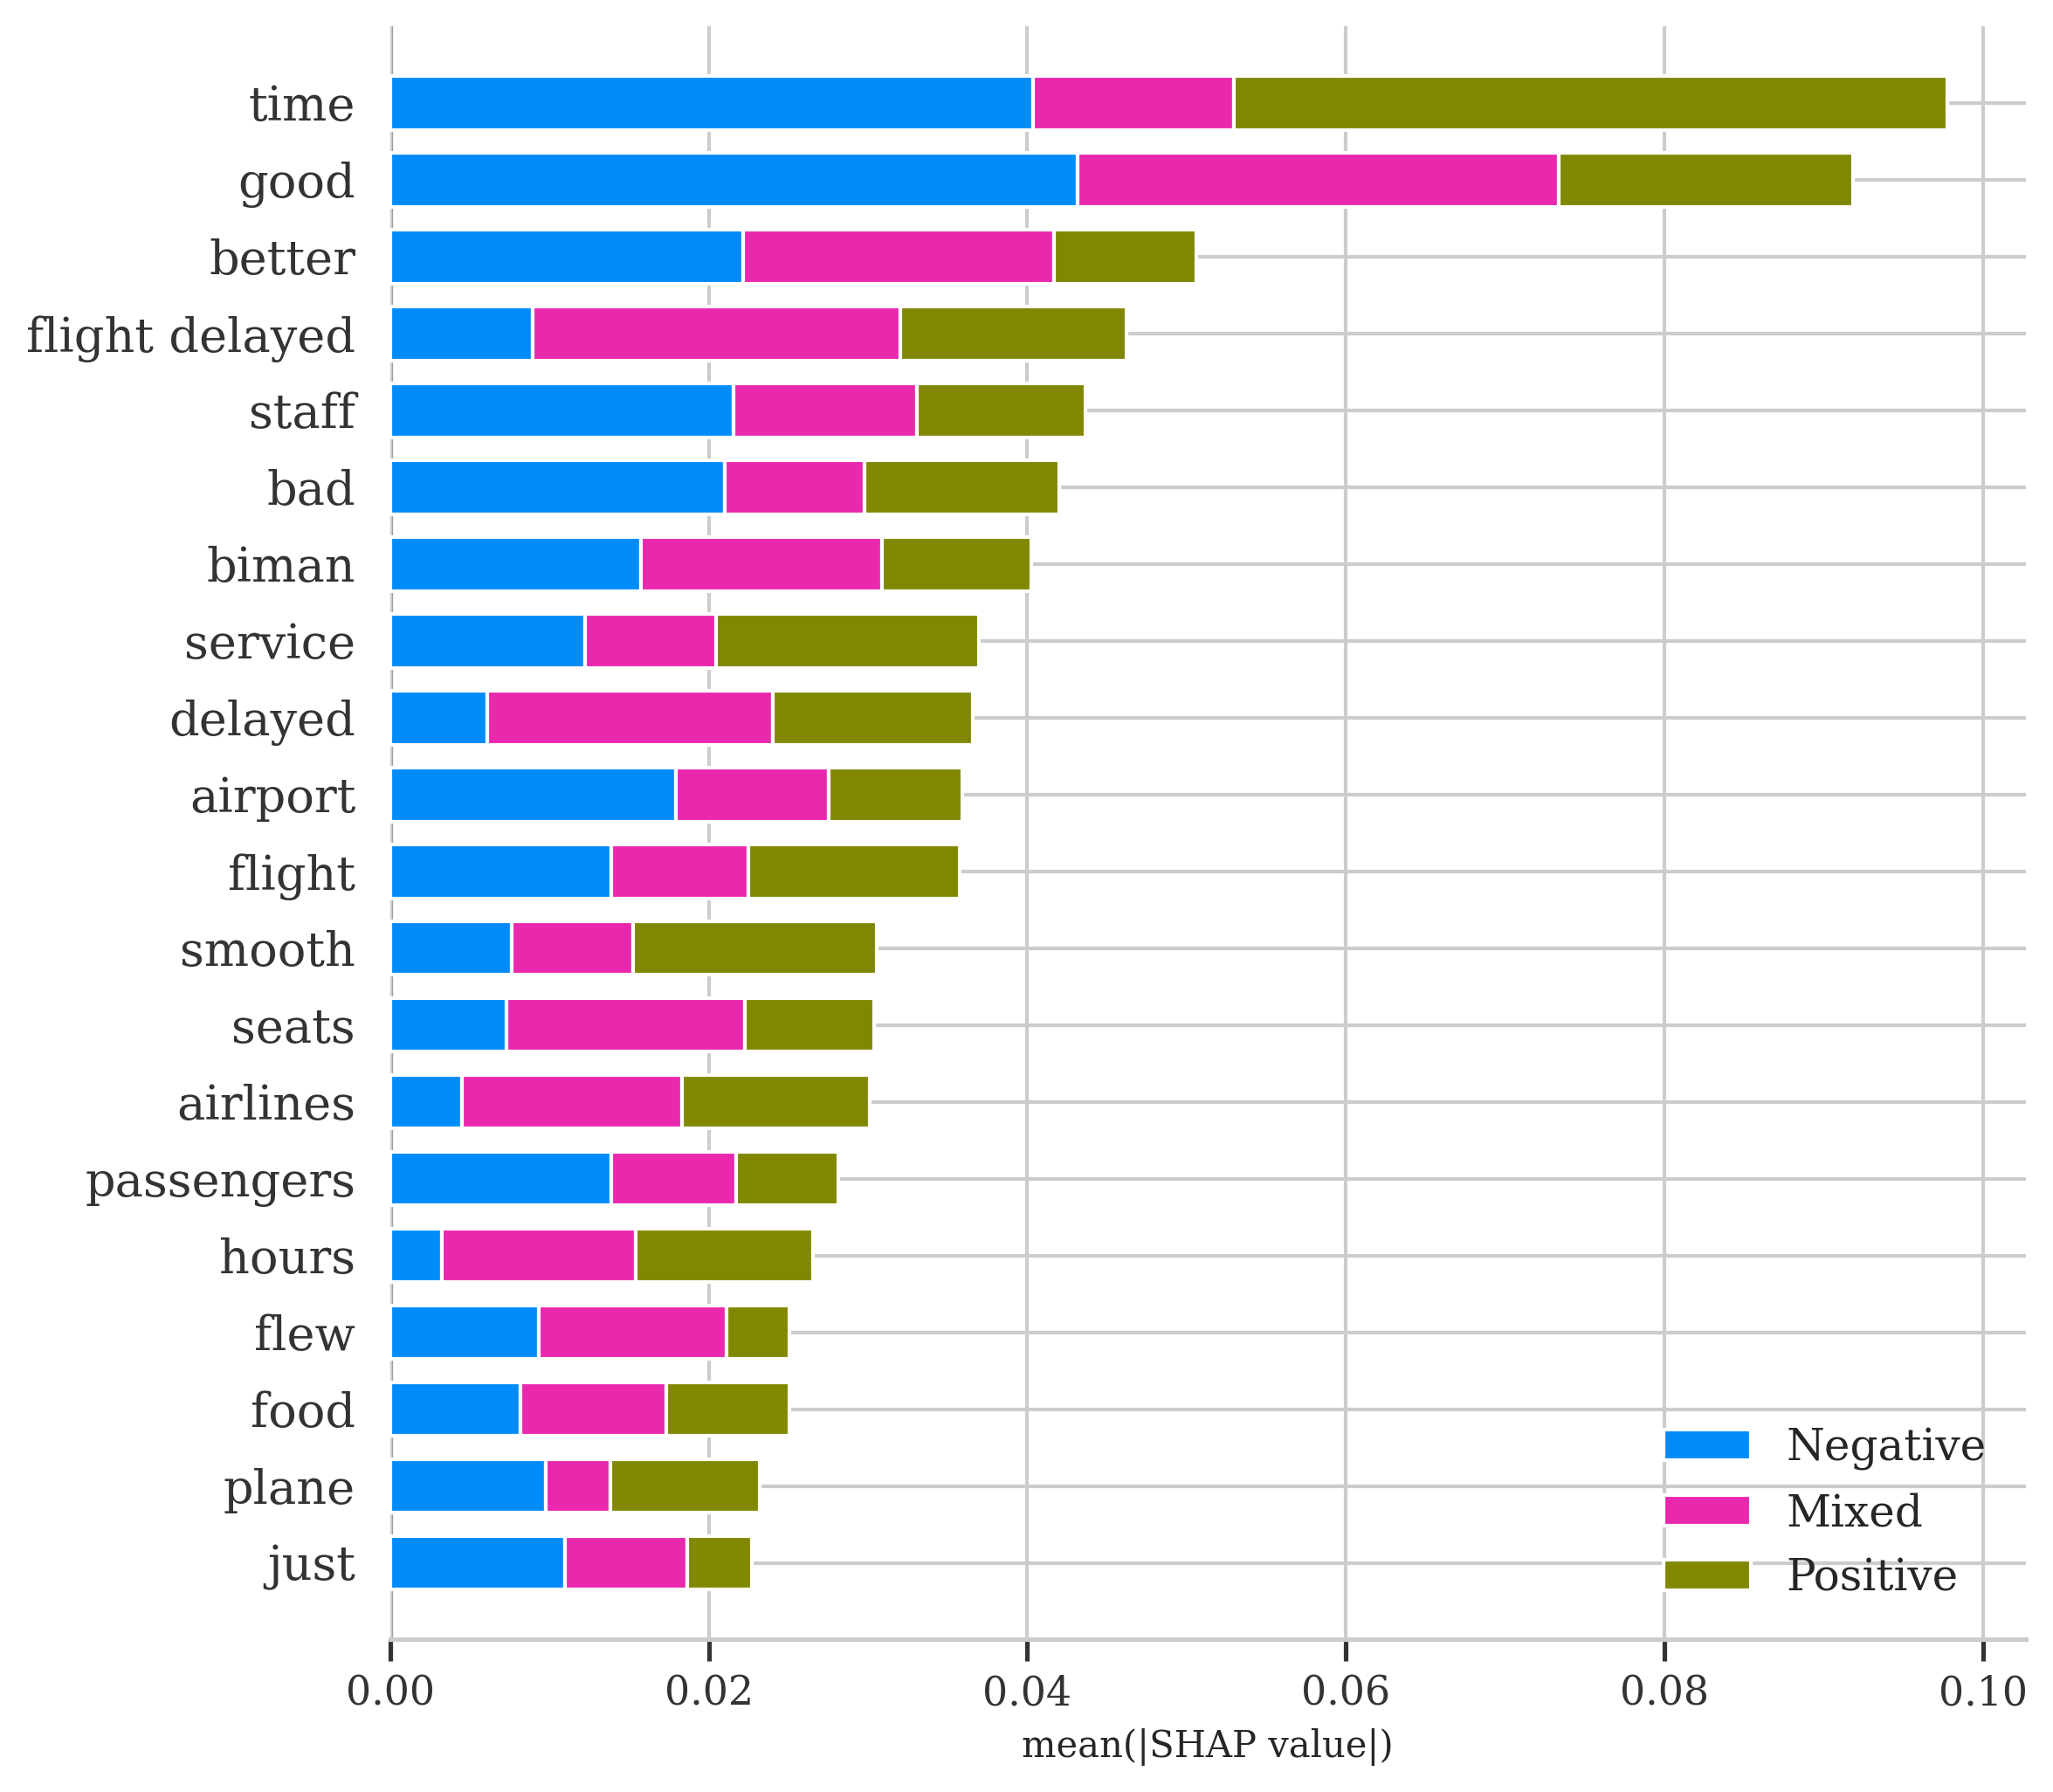

In [39]:
topic_id = 4
topic_mask = df_clean["topic"] == topic_id
X_topic = X[topic_mask]
y_topic = y_sentiment[topic_mask]

clf_topic = RandomForestClassifier(n_estimators=135, random_state=50)
clf_topic.fit(X_topic, y_topic)

explainer_topic = shap.TreeExplainer(clf_topic)
shap_values_topic = explainer_topic.shap_values(X_topic)

fig, ax = plt.subplots(figsize=(8, 7))
plt.sca(ax)
shap.summary_plot(
    shap_values_topic,
    X_topic,
    feature_names=feature_names,
    class_names=list(sentiment_names),
    show=False,
    max_display=20,
    plot_size=None,
    plot_type="bar"
)
ax.set_title("")
ax.set_xlabel("mean(|SHAP value|)", fontsize=10)
plt.tight_layout()
plt.savefig("shap_topic_2.png", dpi=150, bbox_inches="tight")
plt.show()